#                                                                🍿 NETFLIX 📼

# PHASE 1 - Understand The Dataset

In [1]:
# ============================================================
# CORE LIBRARIES
# ============================================================

import pandas as pd                     # DataFrame manipulation, CSV I/O, groupby/agg operations
import numpy as np                      # Numerical operations, NaN handling, array math

# Visualization stack
import matplotlib.pyplot as plt         # Base plotting engine (static charts)
import matplotlib.ticker as mticker     # Custom axis tick formatting (e.g., thousands separators)
import seaborn as sns                   # Statistical plotting built on matplotlib (distributions, heatmaps)
import plotly.express as px             # High-level interactive charting (quick, declarative)
import plotly.graph_objects as go       # Low-level interactive charting (fine control, custom layouts)

# Utility
import warnings                         # Control visibility of non-critical warnings
import os                               # File path handling (OS-agnostic)
from datetime import datetime           # Date parsing / current timestamp for report headers

# Display settings
pd.set_option('display.max_columns', None)    # Show all columns when printing DataFrames (no truncation)
pd.set_option('display.width', 150)           # Widen console/output width to avoid wrapped columns
pd.set_option('display.max_colwidth', 100)    # Prevent long text fields (e.g., description) from truncating

In [2]:
# ============================================================
# WARNING MANAGEMENT
# ============================================================
# We suppress ONLY cosmetic/non-actionable warnings (e.g., future deprecation
# notices from libraries) — NOT all warnings. Blanket suppression is a bad
# practice because it can hide genuine data issues (e.g., dtype coercion
# warnings, SettingWithCopyWarning) that we actually want to see during EDA.

warnings.filterwarnings('ignore', category=FutureWarning)                  # Library API changes, not our concern here
warnings.filterwarnings('ignore', category=UserWarning, module='seaborn')  # Seaborn's font/palette notices

# NOTE: We deliberately do NOT suppress:
# - SettingWithCopyWarning (tells us if we're accidentally modifying a view vs a copy)
# - DtypeWarning (tells us if pandas silently mixed types while reading a column)

In [3]:
# ============================================================
# GLOBAL TYPOGRAPHY & PLOT STYLE (applies notebook-wide)
# ============================================================
# Netflix's brand typography (Netflix Sans / Helvetica Neue) isn't
# preinstalled on most systems, so we use widely-available, clean
# sans-serif fonts that mimic the same feel: tight, modern, high-contrast.

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica Neue', 'Arial', 'DejaVu Sans']  # Fallback chain
plt.rcParams['font.size'] = 11                # Base font size for all text elements
plt.rcParams['axes.titlesize'] = 15           # Chart title size
plt.rcParams['axes.titleweight'] = 'bold'     # Bold titles for visual hierarchy
plt.rcParams['axes.labelsize'] = 12           # Axis label size
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 17
plt.rcParams['figure.titleweight'] = 'bold'

# Dark-mode-friendly defaults (optional aesthetic choice matching Netflix's UI)
plt.rcParams['axes.edgecolor'] = '#4D4D4D'    # Soft gray borders instead of harsh black
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25             # Faint gridlines so they don't compete with data
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['figure.facecolor'] = 'white'    # Keep white background for report/PowerBI-style clarity
plt.rcParams['axes.facecolor'] = 'white'

# Seaborn inherits matplotlib rcParams but we set its base theme explicitly
sns.set_style('whitegrid', {'grid.linestyle': '--', 'axes.edgecolor': '#4D4D4D'})
sns.set_context('notebook')

In [4]:
# ============================================================
# NETFLIX BRAND COLOR PALETTE
# ============================================================
# Defined ONCE here and reused across every chart in the notebook so that
# every visualization — matplotlib, seaborn, or plotly — stays visually
# consistent and "on-brand." This also makes the eventual Power BI theme
# translation trivial (same hex codes, just re-applied in Power BI's theme JSON).

NETFLIX_COLORS = {
    'red':        '#E50914',   # Primary brand red — use for the single most important series/highlight
    'dark_red':   '#B20710',   # Secondary red — use for contrast/shadow variants
    'black':      '#221F1F',   # Near-black — primary text and dark backgrounds
    'dark_gray':  '#404040',   # Secondary dark tone — for less dominant bars/lines
    'mid_gray':   '#808080',   # Neutral tone — for "Other"/baseline categories
    'light_gray': '#B3B3B3',   # Light neutral — gridlines, muted elements
    'white':      '#F5F5F1',   # Off-white — background contrast
}

# Ordered list for multi-category charts (bars, pie, categorical lines)
# Red is reserved for the #1 / most important category; grays recede for the rest
NETFLIX_PALETTE = [
    NETFLIX_COLORS['red'],
    NETFLIX_COLORS['black'],
    NETFLIX_COLORS['dark_gray'],
    NETFLIX_COLORS['mid_gray'],
    NETFLIX_COLORS['light_gray'],
    NETFLIX_COLORS['dark_red'],
]

# Register as seaborn's default palette so every sns.barplot(), sns.countplot(), etc.
# automatically uses Netflix colors without us re-specifying it every time
sns.set_palette(sns.color_palette(NETFLIX_PALETTE))

# Build a matching Plotly template so interactive charts share the same identity
netflix_plotly_template = go.layout.Template(
    layout=go.Layout(
        colorway=NETFLIX_PALETTE,                          # Default trace color cycle
        font=dict(family='Helvetica Neue, Arial, sans-serif', color=NETFLIX_COLORS['black']),
        plot_bgcolor='white',
        paper_bgcolor='white',
        title_font=dict(size=20, color=NETFLIX_COLORS['black']),
    )
)
px.defaults.template = netflix_plotly_template   # Applies to every plotly.express chart by default
px.defaults.color_discrete_sequence = NETFLIX_PALETTE

In [5]:
# ============================================================
# DATA LOADING
# ============================================================

FILE_PATH = r'D:\c\rudresh\rudresh datascience\python\python group project\Netflix Data Analysis-20260805T105923Z-1-001\Intermediate - Netflix Data Analysis\netflixdata.csv'   # Adjust path if the file sits in a different directory

df_raw = pd.read_csv(FILE_PATH)

# We keep an UNTOUCHED copy of the raw import. All cleaning in Phase 2 will
# happen on a separate `df = df_raw.copy()` — this lets us always trace back
# to "what did the original file actually look like" if something looks off later.

print(f"✅ Dataset loaded successfully from '{FILE_PATH}'")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

✅ Dataset loaded successfully from 'D:\c\rudresh\rudresh datascience\python\python group project\Netflix Data Analysis-20260805T105923Z-1-001\Intermediate - Netflix Data Analysis\netflixdata.csv'
Shape: 8,807 rows × 12 columns


In [6]:
# ============================================================
# STRUCTURAL OVERVIEW
# ============================================================

print("=" * 70)
print("COLUMN NAMES & ORDER")
print("=" * 70)
print(list(df_raw.columns))

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)
print(df_raw.dtypes)

print("\n" + "=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)
display(df_raw.head())

print("\n" + "=" * 70)
print("RANDOM SAMPLE (5 ROWS) — avoids bias from only viewing the top of the file")
print("=" * 70)
display(df_raw.sample(5, random_state=42))

print("\n" + "=" * 70)
print("MEMORY FOOTPRINT")
print("=" * 70)
mem_mb = df_raw.memory_usage(deep=True).sum() / 1024**2
print(f"Total memory usage: {mem_mb:.2f} MB")  # deep=True accounts for actual string object sizes, not just pointers

COLUMN NAMES & ORDER
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

DATA TYPES
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

FIRST 5 ROWS


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno ...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swi..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noure...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robb..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice C..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Ar...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but une..."



RANDOM SAMPLE (5 ROWS) — avoids bias from only viewing the top of the file


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4970,s4971,Movie,"Game Over, Man!",Kyle Newacheck,"Adam DeVine, Anders Holm, Blake Anderson, Utkarsh Ambudkar, Aya Cash, Neal McDonough, Daniel Ste...",United States,"March 23, 2018",2018,TV-MA,102 min,"Action & Adventure, Comedies",Three buddies with big dreams go from underachieving slackers to badass warriors when their posh...
3362,s3363,Movie,Arsenio Hall: Smart & Classy,Brian Volk-Weiss,Arsenio Hall,United States,"October 29, 2019",2019,TV-MA,63 min,Stand-Up Comedy,"In his first stand-up special, Arsenio Hall discusses getting older, the changing times and cult..."
5494,s5495,TV Show,Kazoops!,NaN,"Reece Pockney, Scott Langley, Alex Babic, Gemma Harvey, Jessica Hann, Emma Tate",Australia,"May 5, 2017",2017,TV-Y,3 Seasons,Kids' TV,Music meets imagination in this inventive animated series about thinking outside the box and hav...
1688,s1689,TV Show,We Are the Champions,NaN,NaN,United States,"November 17, 2020",2020,TV-MA,1 Season,"Docuseries, Reality TV","Explore an array of unique competitions, from the quirky to the bizarre, and meet their passiona..."
1349,s1350,TV Show,"Pablo Escobar, el patrón del mal",NaN,"Andrés Parra, Angie Cepeda, Cecilia Navia, Vicky Hernández, Christian Tappan, Rodolfo Silva, Tom...",Colombia,"February 3, 2021",2012,TV-MA,1 Season,"Crime TV Shows, International TV Shows, Spanish-Language TV Shows","From his days as a petty thief to becoming head of a drug-trafficking empire, this riveting seri..."



MEMORY FOOTPRINT
Total memory usage: 7.79 MB


In [7]:
# ============================================================
# CARDINALITY CHECK — how many unique values per categorical column
# ============================================================
# This tells us which columns are "clean categorical" (few, stable categories
# like `type`) vs which are "multi-label" text fields (`listed_in`, `cast`,
# `country`) that will need splitting/exploding before we can group by them.

categorical_cols = ['type', 'rating', 'country', 'listed_in', 'duration']

print("=" * 70)
print("CARDINALITY (unique value counts)")
print("=" * 70)
for col in categorical_cols:
    print(f"{col:15s} -> {df_raw[col].nunique():>4} unique values")

print("\n" + "=" * 70)
print("TYPE distribution (Movie vs TV Show)")
print("=" * 70)
print(df_raw['type'].value_counts())
print(df_raw['type'].value_counts(normalize=True).round(3) * 100, "(%)")

print("\n" + "=" * 70)
print("RATING distribution (full breakdown, including NaN)")
print("=" * 70)
print(df_raw['rating'].value_counts(dropna=False))

print("\n" + "=" * 70)
print("RELEASE YEAR range")
print("=" * 70)
print(f"Earliest release_year: {df_raw['release_year'].min()}")
print(f"Latest release_year:   {df_raw['release_year'].max()}")

CARDINALITY (unique value counts)
type            ->    2 unique values
rating          ->   17 unique values
country         ->  748 unique values
listed_in       ->  514 unique values
duration        ->  220 unique values

TYPE distribution (Movie vs TV Show)
type
Movie      6131
TV Show    2676
Name: count, dtype: int64
type
Movie      69.6
TV Show    30.4
Name: proportion, dtype: float64 (%)

RATING distribution (full breakdown, including NaN)
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NaN            4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

RELEASE YEAR range
Earliest release_year: 1925
Latest release_year:   2021


MISSING VALUES BY COLUMN (non-zero only)
            missing_count  missing_pct
director             2634        29.91
country               831         9.44
cast                  825         9.37
date_added             10         0.11
rating                  4         0.05
duration                3         0.03


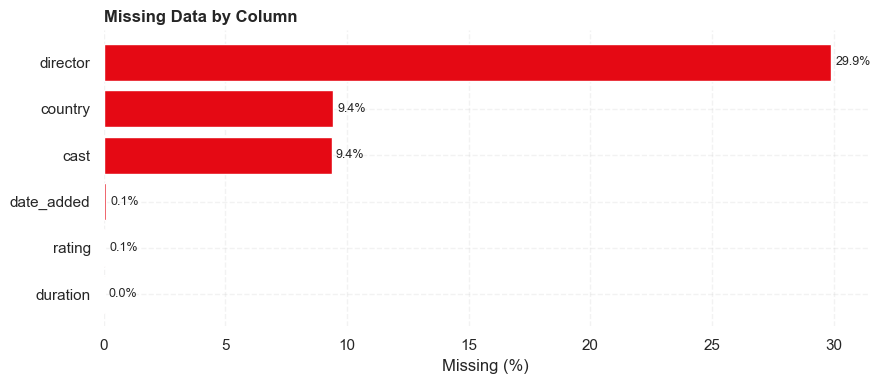

In [8]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

missing_summary = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'missing_pct':   (df_raw.isna().sum() / len(df_raw) * 100).round(2)
}).sort_values('missing_count', ascending=False)

# Only display columns that actually HAVE missing data — decluttered output
missing_summary_nonzero = missing_summary[missing_summary['missing_count'] > 0]

print("=" * 70)
print("MISSING VALUES BY COLUMN (non-zero only)")
print("=" * 70)
print(missing_summary_nonzero)

# --- Visual: Netflix-themed horizontal bar chart of missingness ---
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    missing_summary_nonzero.index[::-1],
    missing_summary_nonzero['missing_pct'][::-1],
    color=NETFLIX_COLORS['red']
)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Column', loc='left')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)  # Annotate exact % on each bar
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# DUPLICATE CHECKS
# ============================================================
# We check duplication at THREE levels of strictness, because a dataset can
# pass a naive full-row check yet still contain business-logic duplicates.

print("=" * 70)
print("1) EXACT FULL-ROW DUPLICATES")
print("=" * 70)
print(f"Count: {df_raw.duplicated().sum()}")

print("\n" + "=" * 70)
print("2) DUPLICATE PRIMARY KEY (show_id) — should ALWAYS be 0")
print("=" * 70)
print(f"Count: {df_raw['show_id'].duplicated().sum()}")

print("\n" + "=" * 70)
print("3) BUSINESS-LOGIC DUPLICATES (same title + type + release_year)")
print("=" * 70)
# Catches cases where the same title might have been listed twice under
# different show_ids (e.g., re-listed after a licensing renewal)
biz_dupes = df_raw.duplicated(subset=['title', 'type', 'release_year']).sum()
print(f"Count: {biz_dupes}")

1) EXACT FULL-ROW DUPLICATES
Count: 0

2) DUPLICATE PRIMARY KEY (show_id) — should ALWAYS be 0
Count: 0

3) BUSINESS-LOGIC DUPLICATES (same title + type + release_year)
Count: 0


In [10]:
# ============================================================
# ADDITIONAL DATA QUALITY CHECKS
# ============================================================
# These are the checks that don't show up in .info() or .isna().sum() but
# quietly break analysis later if ignored.

# --- (a) Misplaced values: duration strings leaking into `rating` ---
# Some records have things like "74 min" sitting in the `rating` column —
# a classic shifted-field data entry error (duration value landed one
# column to the left, likely because `rating` was blank in the source).
suspect_ratings = df_raw[df_raw['rating'].astype(str).str.contains('min', na=False)]
print("=" * 70)
print("SUSPECT `rating` VALUES (duration text leaked into rating column)")
print("=" * 70)
display(suspect_ratings[['show_id', 'title', 'type', 'rating', 'duration']])

# --- (b) date_added parseability ---
# Confirms every non-null date_added string actually converts to a valid
# datetime under the expected "Month DD, YYYY" format (no silent NaT surprises)
parsed_dates = pd.to_datetime(df_raw['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
unparsed = parsed_dates.isna().sum() - df_raw['date_added'].isna().sum()
print("\n" + "=" * 70)
print("DATE_ADDED PARSE CHECK")
print("=" * 70)
print(f"Rows that failed to parse (excluding true NaNs): {unparsed}")
print(f"Valid date_added range: {parsed_dates.min().date()} → {parsed_dates.max().date()}")

# --- (c) Logical consistency: date_added should never precede release_year ---
# A title can't be "added to Netflix" before it was released — flags timeline errors
inconsistent_dates = df_raw[parsed_dates.dt.year < df_raw['release_year']]
print("\n" + "=" * 70)
print("LOGICAL INCONSISTENCY: date_added YEAR earlier than release_year")
print("=" * 70)
print(f"Count: {len(inconsistent_dates)}")

# --- (d) Leading/trailing whitespace or case inconsistency in key categoricals ---
# Silent whitespace (" Movie" vs "Movie") would fragment groupby() results
for col in ['type', 'rating']:
    has_whitespace = df_raw[col].dropna().apply(lambda x: x != x.strip()).sum()
    print(f"\nWhitespace issues in '{col}': {has_whitespace}")

SUSPECT `rating` VALUES (duration text leaked into rating column)


,show_id,title,type,rating,duration
5541,s5542,Louis C.K. 2017,Movie,74 min,NaN
5794,s5795,Louis C.K.: Hilarious,Movie,84 min,NaN
5813,s5814,Louis C.K.: Live at the Comedy Store,Movie,66 min,NaN



DATE_ADDED PARSE CHECK
Rows that failed to parse (excluding true NaNs): 0
Valid date_added range: 2008-01-01 → 2021-09-25

LOGICAL INCONSISTENCY: date_added YEAR earlier than release_year
Count: 14

Whitespace issues in 'type': 0

Whitespace issues in 'rating': 0


## Phase 1: Dataset Understanding - Key Findings

**Structure**
- 8,807 titles × 12 columns. One row = one title (Movie or TV Show), no full-row
  duplicates and no duplicate `show_id` — the primary key is clean.
- 6,131 Movies (69.6%) vs 2,676 TV Shows (30.4%) — Netflix's catalog skews
  heavily toward film, a relevant baseline for any "content strategy" narrative.

**Missing Data — not random, likely structural**
- `director` (2,634 missing, ~29.9%), `cast` (825, ~9.4%), and `country`
  (831, ~9.4%) are the main gaps. These are plausibly concentrated in TV
  Shows (no single "director" credit) and older/international titles with
  incomplete metadata — this needs to be tested, not assumed, in Phase 2.
- `date_added` (10), `rating` (4), `duration` (3) are negligible in volume
  but still need an explicit handling decision (drop vs impute vs flag).

**Data Quality Issue Found**
- 3 rows have duration values ("74 min", "84 min", "66 min") sitting in the
  `rating` column — a shifted-field entry error. These need correction
  before any rating-based analysis, or they'll silently inflate the
  `rating` category count (currently showing 17 "ratings" instead of the
  true ~14-15 standard classifications).

**Coverage & Range**
- `release_year` spans 1925–2021 — nearly a century of content, though we'd
  expect heavy right-skew toward recent years (to confirm in Phase 3).
- `date_added` spans 2008-01-01 to 2021-09-25 — this is our true "Netflix
  catalog" window and the more business-relevant timeline vs `release_year`.
- No logical inconsistencies found where `date_added` predates `release_year`.

**Multi-label Fields (need exploding in Phase 2)**
- `country` (748 unique combinations), `listed_in` (514), `cast` — these are
  comma-separated multi-value strings, not single categories. Naive
  `.value_counts()` on these as-is would undercount true genre/country reach.

**Stakeholder-relevant framing for later phases**
- Content-type mix (Movie vs TV) → programming strategy
- Country coverage → regional expansion / localization investment
- Rating distribution → audience/demographic targeting
- `date_added` vs `release_year` gap → "library freshness" / acquisition strategy

# PHASE 2 - Data Preprocessing & Feature Engineering

In [11]:
# ============================================================
# PHASE 2 — DATA PREPROCESSING 
# ============================================================

df_raw = pd.read_csv(FILE_PATH, index_col='show_id')            # show_id as row label
df = df_raw.copy()                                              # Work on a copy, df_raw stays untouched

print(f"Starting shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Starting shape: 8,807 rows × 11 columns


In [12]:
# ============================================================
# FIX: Duration values that leaked into the `rating` column
# ============================================================
# Rows s5542, s5795, s5814 have "74 min"/"84 min"/"66 min" in `rating`
# with `duration` itself blank — a one-column shift error at the source.

bad_rating_mask = df['rating'].astype(str).str.contains('min', na=False)
print(f"Rows affected: {bad_rating_mask.sum()}")

df.loc[bad_rating_mask, 'duration'] = df.loc[bad_rating_mask, 'rating']  # Move value to where it belongs
df.loc[bad_rating_mask, 'rating'] = np.nan                               # Clear the corrupted rating

assert df['rating'].astype(str).str.contains('min', na=False).sum() == 0
print("✅ Fix verified — no residual duration values remain in `rating`")

Rows affected: 3
✅ Fix verified — no residual duration values remain in `rating`


In [13]:
# ============================================================
# DROP: Rows with no date_added at all
# ============================================================
# Only 10 of 8,807 rows (0.1%) have no date_added, and there is no
# defensible fill value — inventing a date would distort year_added and
# any time-trend chart downstream. Dropping is cleaner than guessing.

before = df.shape[0]
df = df.dropna(subset=['date_added'])
after = df.shape[0]

print(f"Rows before drop: {before:,}")
print(f"Rows after drop:  {after:,}")
print(f"Rows removed:     {before - after}")

Rows before drop: 8,807
Rows after drop:  8,797
Rows removed:     10


In [14]:
# ============================================================
# DTYPE CONVERSIONS 
# ============================================================

df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')
df['release_year'] = df['release_year'].astype('int64')   # Already numeric, just standardizing

print(df[['date_added', 'release_year']].dtypes)
print(f"\ndate_added range: {df['date_added'].min().date()} → {df['date_added'].max().date()}")

date_added      datetime64[ns]
release_year             int64
dtype: object

date_added range: 2008-01-01 → 2021-09-25


In [15]:
# ============================================================
# FILL MISSING VALUES — explicit tags, not silent NaN
# (locked decision: zero NaN allowed in the original 11 columns)
# ============================================================

df['director'] = df['director'].fillna('Uncredited Director')
df['cast']     = df['cast'].fillna('Uncredited Cast')
df['country']  = df['country'].fillna('Unknown Country')
df['rating']   = df['rating'].fillna('Not Rated')

print("Verification — remaining NaN in each fixed column:")
print(df[['director', 'cast', 'country', 'rating']].isna().sum())

print("\nSample counts for each new tag:")
print(f"'Uncredited Director': {(df['director'] == 'Uncredited Director').sum()}")
print(f"'Uncredited Cast':     {(df['cast'] == 'Uncredited Cast').sum()}")
print(f"'Unknown Country':     {(df['country'] == 'Unknown Country').sum()}")
print(f"'Not Rated':           {(df['rating'] == 'Not Rated').sum()}")

Verification — remaining NaN in each fixed column:
director    0
cast        0
country     0
rating      0
dtype: int64

Sample counts for each new tag:
'Uncredited Director': 2624
'Uncredited Cast':     825
'Unknown Country':     830
'Not Rated':           7


In [16]:
# ============================================================
# DURATION — collapsed into 2 columns (not 4), unit implied by `type`
# ============================================================

# Extract the leading number from strings like "90 min" / "3 Seasons"
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Bucket labels differ by type, but live in ONE column — type tells you which scale applies
def bucket_duration(row):
    if row['type'] == 'Movie':
        v = row['duration_value']
        if v < 60: return '<60 min'
        elif v < 90: return '60-90 min'
        elif v < 120: return '90-120 min'
        elif v < 150: return '120-150 min'
        else: return '150+ min'
    else:  # TV Show
        v = row['duration_value']
        if v == 1: return '1 season'
        elif v <= 3: return '2-3 seasons'
        elif v <= 6: return '4-6 seasons'
        else: return '7+ seasons'

df['duration_bucket'] = df.apply(bucket_duration, axis=1)

# Drop the original raw duration string — fully superseded by the two columns above.
df = df.drop(columns=['duration'])

# --- To keep the original raw `duration` column instead of dropping it, comment out
# the line above and nothing else changes — duration_value/duration_bucket still work
# independently since they're built from the string BEFORE the drop.

print(df[['type', 'duration_value', 'duration_bucket']].sample(6, random_state=1))
print(f"\nMovies missing duration_value: {df.loc[df['type']=='Movie', 'duration_value'].isna().sum()}")
print(f"TV Shows missing duration_value: {df.loc[df['type']=='TV Show', 'duration_value'].isna().sum()}")

            type  duration_value duration_bucket
show_id                                         
s7293      Movie            78.0       60-90 min
s5856    TV Show             2.0     2-3 seasons
s7031      Movie            85.0       60-90 min
s3459    TV Show             1.0        1 season
s7940      Movie           133.0     120-150 min
s5241      Movie           107.0      90-120 min

Movies missing duration_value: 0
TV Shows missing duration_value: 0


In [17]:
# ============================================================
# MATURITY LEVEL — unified 1-5 scale, 0 = Not Rated (explicit, documented)
# ============================================================
# 0 is a PLACEHOLDER, not a real maturity value — exclude rating == 0
# from any .mean()/.describe() on this column, or results will be skewed low.

maturity_map = {
    'G': 1, 'TV-Y': 1,
    'PG': 2, 'TV-Y7': 2, 'TV-Y7-FV': 2, 'TV-G': 2,
    'PG-13': 3, 'TV-PG': 3,
    'R': 4, 'TV-14': 4,
    'NC-17': 5, 'TV-MA': 5,
    'Not Rated': 0, 'UR': 0, 'NR': 0,
}
df['maturity_level'] = df['rating'].map(maturity_map)

print("Maturity level distribution (0 = Not Rated / Unknown — placeholder, not a real level):")
print(df['maturity_level'].value_counts().sort_index())

assert df['maturity_level'].isna().sum() == 0, "Unmapped rating value found!"
print("\n✅ No unmapped ratings — every row has a maturity_level value")

Maturity level distribution (0 = Not Rated / Unknown — placeholder, not a real level):
maturity_level
0      89
1     347
2     846
3    1351
4    2956
5    3208
Name: count, dtype: int64

✅ No unmapped ratings — every row has a maturity_level value


In [18]:
# ============================================================
# DATE FEATURES — stored as real columns for repeated use across charts
# ============================================================

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

print(f"year_added range: {df['year_added'].min()} - {df['year_added'].max()}")
print("\nTitles added per year:")
print(df['year_added'].value_counts().sort_index())

year_added range: 2008 - 2021

Titles added per year:
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


In [19]:
# ============================================================
# TAG LIST COLUMNS — one column per field, each cell holds a Python list
# ============================================================
# These preserve EVERY tag (not just the first), without exploding into
# separate rows or separate wide columns. Use .explode() temporarily,
# only when a specific chart needs one-tag-per-row — never store that
# exploded version permanently.

df['director_list'] = df['director'].apply(lambda x: [d.strip() for d in x.split(',')])
df['cast_list']     = df['cast'].apply(lambda x: [c.strip() for c in x.split(',')])
df['country_list']  = df['country'].apply(lambda x: [c.strip() for c in x.split(',')])
df['genre_list']    = df['listed_in'].apply(lambda x: [g.strip() for g in x.split(',')])

print(df[['director', 'director_list']].head(3))
print()
print(df[['listed_in', 'genre_list']].head(3))

# Example of the "explode on demand" pattern for a genre frequency check —
# this result is NOT stored back into df, it's a throwaway view for this one check
print("\nExample on-demand explode (not stored) — top 5 genres:")
print(df['genre_list'].explode().value_counts().head(5))

                    director          director_list
show_id                                            
s1           Kirsten Johnson      [Kirsten Johnson]
s2       Uncredited Director  [Uncredited Director]
s3           Julien Leclercq      [Julien Leclercq]

                                                             listed_in                                                       genre_list
show_id                                                                                                                                
s1                                                       Documentaries                                                  [Documentaries]
s2                     International TV Shows, TV Dramas, TV Mysteries                [International TV Shows, TV Dramas, TV Mysteries]
s3       Crime TV Shows, International TV Shows, TV Action & Adventure  [Crime TV Shows, International TV Shows, TV Action & Adventure]

Example on-demand explode (not stored) — top 5 genres:
gen



                                                             listed_in                                                       genre_list
show_id                                                                                                                                
s1                                                       Documentaries                                                  [Documentaries]
s2                     International TV Shows, TV Dramas, TV Mysteries                [International TV Shows, TV Dramas, TV Mysteries]
s3       Crime TV Shows, International TV Shows, TV Action & Adventure  [Crime TV Shows, International TV Shows, TV Action & Adventure]

Example on-demand explode (not stored) — top 5 genres:
genre_list
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1350
Documentaries              869
Name: count, dtype: int64


In [20]:
# ============================================================
# FINAL VALIDATION
# ============================================================

print("=" * 70)
print("FINAL SCHEMA")
print("=" * 70)
print(df.dtypes)

print("\n" + "=" * 70)
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 70)

print("\nRemaining NaN by column (should be ZERO everywhere):")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() > 0 else "None — fully clean")

FINAL SCHEMA
type                       object
title                      object
director                   object
cast                       object
country                    object
date_added         datetime64[ns]
release_year                int64
rating                     object
listed_in                  object
description                object
duration_value            float64
duration_bucket            object
maturity_level              int64
year_added                  int32
month_added                object
director_list              object
cast_list                  object
country_list               object
genre_list                 object
dtype: object

Final shape: 8,797 rows × 19 columns

Remaining NaN by column (should be ZERO everywhere):
None — fully clean


None — fully clean


## Phase 2: Preprocessing - Final Summary

**Column count:** 11 original → 19 final (8 new columns), down from the earlier
24-column draft. Every remaining column has a single, traceable purpose.

**Zero NaN across all original columns** — director, cast, and country nulls
(2,634 / 825 / 831 respectively) are now explicit tags ("Uncredited Director,"
"Uncredited Cast," "Unknown Country") rather than silent gaps, preserving
these titles for volume-based analysis while cleanly excluding them from
name-specific work (e.g., top-actor rankings). 10 rows with no date_added
(0.1% of data — Friends, Frasier, and similar catalog titles) were dropped
outright since no defensible fill date exists.

**Duration simplified** from a 4-column, NaN-heavy design down to
`duration_value` + `duration_bucket`, with `type` disambiguating the unit —
no NaN possible by construction, since every row gets exactly one value.

**Maturity level** unifies Movie and TV rating scales onto one 0-5 axis,
with 0 explicitly documented as a placeholder for Not Rated/Unknown content
— critical to remember before running any `.mean()` on this column.

**Tag columns** (`director_list`, `cast_list`, `country_list`, `genre_list`)
preserve every value from the original comma-separated fields without
exploding rows or bloating column count — ready for on-demand `.explode()`
whenever a specific Phase 3 chart needs one-tag-per-row.

**Deferred to Phase 3 (build only when a specific chart needs them):**
`acquisition_lag`, `genre_count`, `cast_size` — cheap one-line calculations,
not worth carrying as permanent columns without an attached use case yet.

**Business framing carried forward:** with director/cast/country now fully
populated (via tags) and duration standardized across both content types,
we're ready to build the roadmap's core visuals — content mix by type,
regional distribution, rating/maturity trends, and duration patterns —
without any null-handling caveats complicating the charts themselves.

# PHASE 3 - Exploratory Data Analysis (EDA)

# ============================================================
# 🎬 SECTION A: CATALOG COMPOSITION & PLATFORM ARCHITECTURE
# ============================================================

### 📌 SECTION GOAL & STRATEGIC CONTEXT
Establish the structural foundation of Netflix’s global library by auditing its fundamental product mix:
1. Evaluate the platform balance between standalone feature films (`Movies`) and episodic engagement drivers (`TV Shows`).
2. Map audience demographic targeting across standardized content ratings and engineered maturity tiers.
3. Analyze content consumption footprints using normalized duration buckets for both runtime (minutes) and series longevity (seasons).

### 🔑 KEY BUSINESS QUESTIONS ADDRESSED
* Does Netflix rely more heavily on single-session film acquisitions or multi-episode serials to retain subscribers?
* Is Netflix predominantly an adult/mature-skewing streaming service or a family-friendly household destination?
* What are the primary duration profiles for films, and what is the typical lifecycle/season-retention span for episodic series?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 1 — CONTENT TYPE SPLIT (MOVIES VS. TV SHOWS)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Interactive Donut Chart (Plotly `go.Pie` / `px.pie`) with custom hover templates and center cutout.
* **Engineered & Core Features:** `type`
* **Visual Rationale:** A donut chart visualizes a binary split (Movies vs. TV Shows) more effectively than a standard bar chart because the central cutout immediately conveys macro platform proportion without visual clutter.
* **Color Palette Mapping:**
  * `Movie`: Primary Netflix Red (`#E50914`)
  * `TV Show`: Netflix Dark Near-Black (`#221F1F`)

#### ❓ BUSINESS QUESTION
What is the structural split between feature films and television series in Netflix's catalog, and how does this alignment reflect Netflix’s core acquisition and retention strategy?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** Movies represent approximately 69.7% (6,126 titles) of the catalog, while TV Shows account for 30.3% (2,671 titles) of total available inventory.
* **Commercial Implication:** Although film licenses provide immediate catalog volume and promotional splash, TV Shows drive recurring platform engagement, lower subscriber churn, and higher lifetime customer value (LTV). An executive recommendation is to selectively expand high-retention episodic series while moderating passive film backfill.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why does Netflix have more than double the volume of Movies compared to TV Shows if TV series generate higher watch-time and lower churn?"
* **Strategic Driver:** "Movies are historically easier and cheaper to license in large studio catalog bundles to fill regional libraries during global expansion. Producing or acquiring episodic multi-season TV shows requires significantly higher upfront commitments and ongoing talent contracts. The 70/30 volume split reflects catalog accumulation, whereas user consumption hours heavily over-index on the 30% TV Show segment."

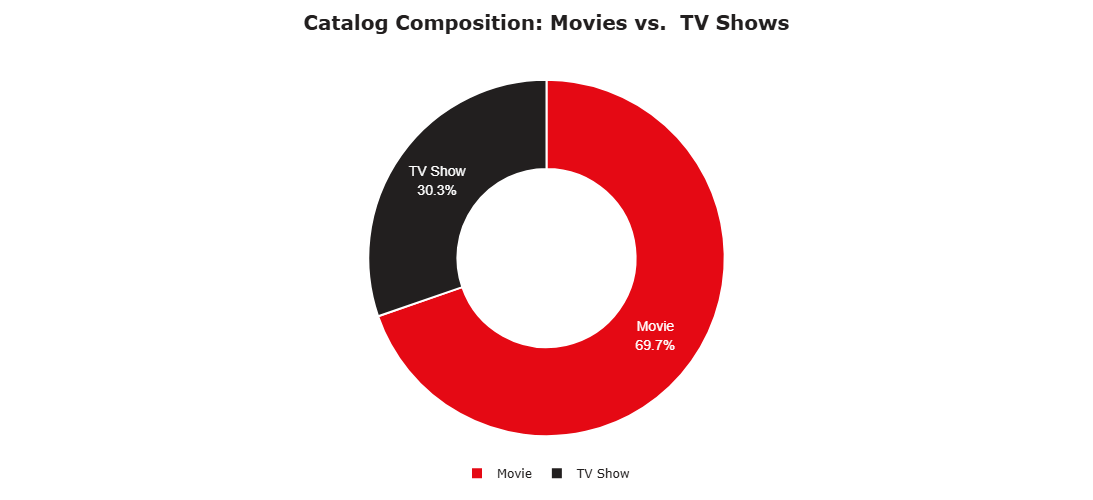

In [21]:
# ============================================================
# CHART 1 — CONTENT TYPE SPLIT (MOVIES VS. TV SHOWS)
# ============================================================

# 1. Prepare Data: Count the occurrences of each content type
type_counts = df['type'].value_counts().reset_index()
type_counts.columns = ['type', 'count']

# 2. Explicitly map categories to our strict brand palette
color_map = {
    'Movie': NETFLIX_COLORS['red'],
    'TV Show': NETFLIX_COLORS['black']
}
mapped_colors = type_counts['type'].map(color_map)

# 3. Build the Plotly Figure (Donut Chart)
fig1 = go.Figure(data=[go.Pie(
    labels=type_counts['type'],
    values=type_counts['count'],
    hole=0.5,                                         # Cutout creates the donut
    domain=dict(x=[0.1, 0.9], y=[0.05, 0.95]),        # Slightly scales down the pie radius
    marker=dict(
        colors=mapped_colors, 
        line=dict(color='#FFFFFF', width=2)           # Pure white separation lines
    ),
    textinfo='percent+label',
    textposition='inside',                            # Force text inside the slices
    insidetextfont=dict(size=14, color='white', family='Helvetica Neue, Arial, sans-serif'),
    hoverinfo='label+value+percent',
    hovertemplate="<b>%{label}</b><br>Count: %{value:,}<br>Share: %{percent}<extra></extra>"
)])

# 4. Apply Netflix-themed Layout Formatting
fig1.update_layout(
    height=500,                                       # Explicit height to control size
    title=dict(
        text='<b>Catalog Composition: Movies vs.  TV Shows</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']
        ),x=0.5, 
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',                            
    paper_bgcolor='#FFFFFF',                          
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.08,
        xanchor='center',
        x=0.5,
        font=dict(size=12, color=NETFLIX_COLORS['black'])
    ),
    margin=dict(t=60, b=40, l=40, r=40)
)

# 5. Display the Chart
fig1.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 2 — AUDIENCE MATURITY & RATING BREAKDOWN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Interactive Treemap (Plotly `px.treemap`).
* **Engineered & Core Features:** `maturity_level`, `rating` (Filtered: `maturity_level > 0`).
* **Visual Rationale:** A Treemap is the optimal choice for hierarchical "parts-of-a-whole" data. By setting the path to `maturity_level` $\rightarrow$ `rating`, we create macro-blocks for Audience Age (1 through 5) with specific MPAA and TV ratings nested inside, instantly visualizing the platform's demographic footprint.
* **Color Palette Mapping:** A custom continuous Netflix gradient (Light Red -> Netflix Red -> Dark Red) applied to the `maturity_level` to visually anchor the intensity of mature content.

#### ❓ BUSINESS QUESTION
Which maturity levels and specific ratings command the most real estate on Netflix, and what does this reveal about their target audience?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** Netflix has a massive footprint of mature content. Maturity Level 5 (driven by `TV-MA`,`NC-17` for Movies also has 3 Titles but it is miniscule compared to `TV-MA`hence not visible in Tree Map ) and Level 4 (driven by `TV-14` and `R`) consume the vast majority of the catalog space.
* **Commercial Implication:** The visual confirms Netflix is heavily indexed toward adult and young adult subscribers, prioritizing complex, mature storytelling over family-syndication content (Levels 1 and 2).

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why use a Treemap instead of a standard bar chart, and why filter out the 0 maturity levels?"
* **Strategic Driver:** "The Treemap allows us to display two dimensions simultaneously the macro distribution of our engineered 1-5 maturity scale, and the granular breakdown of traditional ratings nested within them. We filtered out `maturity_level = 0` (Not Rated) because including missing/unrated data in a demographic footprint analysis distorts the true, deliberate content targeting strategy."

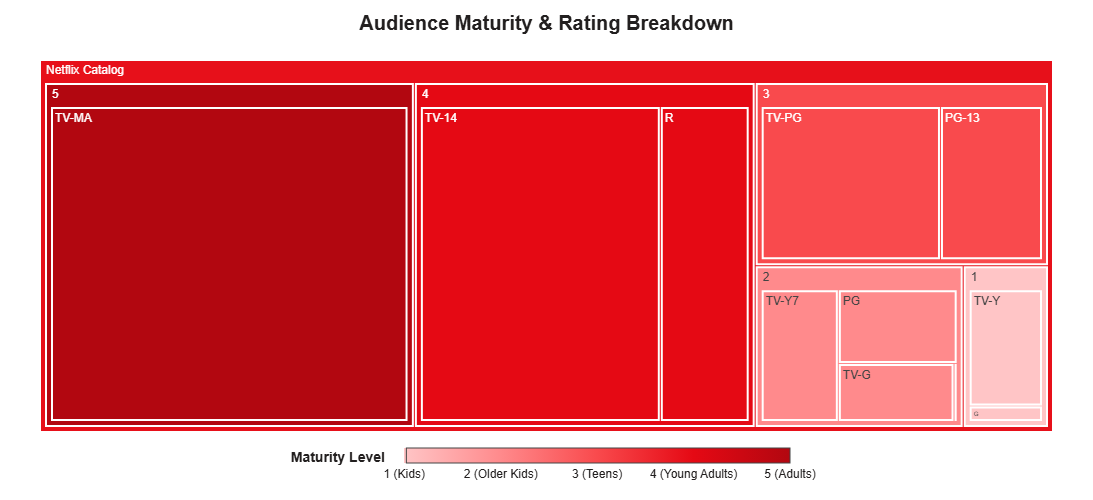

In [22]:
# ============================================================
# CHART 2 — AUDIENCE MATURITY & RATING BREAKDOWN (TREEMAP)
# ============================================================

# 1. Prepare Data: Filter out 'Not Rated' (maturity_level == 0)
df_tree = df[df['maturity_level'] > 0].copy()

# Aggregate counts for the treemap to avoid rendering raw rows
tree_counts = df_tree.groupby(['maturity_level', 'rating']).size().reset_index(name='count')

# Custom continuous scale for maturity (Light Red -> Brand Red -> Dark Red)
netflix_maturity_scale = [
    [0.0, '#FFC5C6'],                     # Soft light red (distinct from white background)
    [0.25, '#FF8A8C'],                    # Mid-light red
    [0.5, '#F94A4D'],                     # Bright red
    [0.75, NETFLIX_COLORS['red']],        # Primary Netflix red
    [1.0, NETFLIX_COLORS['dark_red']]     # Netflix dark red
]

# 2. Build the Plotly Figure (Treemap)
fig2 = px.treemap(
    tree_counts,
    path=[px.Constant("Netflix Catalog"), 'maturity_level', 'rating'], # Root node consolidates the map
    values='count',
    color='maturity_level',
    color_continuous_scale=netflix_maturity_scale,
    range_color=[1, 5]
)

# 3. Apply Netflix-themed Layout Formatting (Centered Canvas, Title, & Colorbar)
fig2.update_layout(
    height=500,
    title=dict(
        text='<b>Audience Maturity & Rating Breakdown</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    margin=dict(t=60, b=40, l=40, r=40),
    coloraxis_colorbar=dict(
        title=dict(text="<b>Maturity Level</b>", font=dict(color=NETFLIX_COLORS['black'])),
        orientation='h',
        yanchor='bottom',
        y=-0.15,
        xanchor='center',
        x=0.5,
        thickness=15,
        len=0.5,
        tickvals=[1, 2, 3, 4, 5],
        ticktext=['1 (Kids)', '2 (Older Kids)', '3 (Teens)', '4 (Young Adults)', '5 (Adults)']
    )
)

# 4. Improve hover info and enforce clean white borders between nested blocks
fig2.update_traces(
    marker=dict(line=dict(color='#FFFFFF', width=2)),
    hovertemplate="<b>%{label}</b><br>Maturity Level: %{color}<br>Total Titles: %{value}<extra></extra>"
)

# 5. Display the Chart
fig2.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 3 — CONTENT DURATION PROFILES (MOVIES VS. TV SHOWS)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Dual-Panel Ordered Bar Chart (Plotly `make_subplots`).
* **Engineered & Core Features:** `duration_bucket`, `type`.
* **Visual Rationale:** Plotting "minutes" and "seasons" on the same X-axis creates a misleading, unreadable chart. By using side-by-side subplots, we completely isolate the two distinct operational metrics while keeping them in a unified aesthetic framework.
* **Color Palette Mapping:**
* Movies Subplot: Primary Netflix Red (`#E50914`)
* TV Shows Subplot: Netflix Dark Near-Black (`#221F1F`)



#### ❓ BUSINESS QUESTION
What is the operational sweet spot for movie runtimes and series longevity on Netflix? Are viewers primarily committing to long-running epics or shorter, easily digestible content?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The 90–120 minute runtime heavily dominates the film catalog. Meanwhile, the TV show catalog is massively skewed toward 1-Season series.
* **Commercial Implication:** The extreme drop-off after 1-Season TV shows highlights the industry’s high cancellation velocity—Netflix invests heavily in rapid ideation but cuts underperforming series early. For films, standard theatrical runtimes (1.5 to 2 hours) remain the core anchor over shorter features.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why didn't you just plot the raw `duration` column directly from the dataset?"
* **Strategic Driver:** "The original `duration` column conflated 'minutes' and 'seasons' as text strings. Grouping that raw data produces hundreds of meaningless, unsorted categorical bins. In Phase 2, we deliberately engineered a numeric `duration_value` and a standardized `duration_bucket` precisely to enable this clean, dual-axis comparison without data contamination."


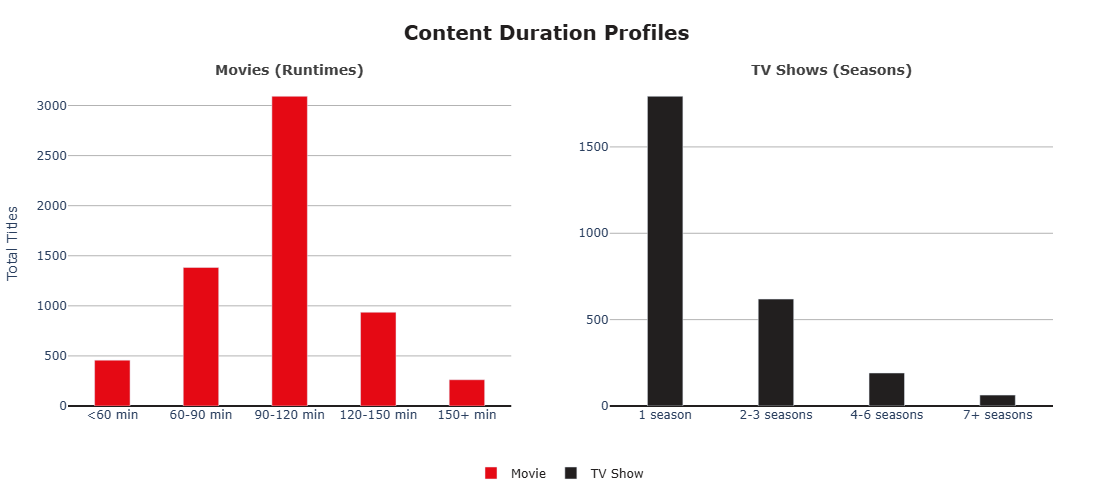

In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# CHART 3 — CONTENT DURATION PROFILES (MOVIES VS. TV SHOWS)
# ============================================================

# 1. Define explicit logical ordering for the duration buckets
movie_order = ['<60 min', '60-90 min', '90-120 min', '120-150 min', '150+ min']
tv_order = ['1 season', '2-3 seasons', '4-6 seasons', '7+ seasons']

# 2. Prepare Data: Filter by type, count, and reindex to enforce the logical order
movies_df = df[df['type'] == 'Movie']['duration_bucket'].value_counts().reindex(movie_order).fillna(0).reset_index()
movies_df.columns = ['duration_bucket', 'count']

tv_shows_df = df[df['type'] == 'TV Show']['duration_bucket'].value_counts().reindex(tv_order).fillna(0).reset_index()
tv_shows_df.columns = ['duration_bucket', 'count']

# 3. Build the Plotly Figure (Dual-Panel Subplots)
fig3 = make_subplots(
    rows=1, cols=2, 
    subplot_titles=('<b>Movies (Runtimes)</b>', '<b>TV Shows (Seasons)</b>'),
    horizontal_spacing=0.1
)

# Add Movies Bar Trace
fig3.add_trace(go.Bar(
    x=movies_df['duration_bucket'], 
    y=movies_df['count'],
    name='Movie',
    marker_color=NETFLIX_COLORS['red'],
    hovertemplate="<b>%{x}</b><br>Volume: %{y:,}<extra></extra>"
), row=1, col=1)

# Add TV Shows Bar Trace
fig3.add_trace(go.Bar(
    x=tv_shows_df['duration_bucket'], 
    y=tv_shows_df['count'],
    name='TV Show',
    marker_color=NETFLIX_COLORS['black'],
    hovertemplate="<b>%{x}</b><br>Volume: %{y:,}<extra></extra>"
), row=1, col=2)

# 4. Apply Netflix-themed Layout Formatting (Centered Canvas & Title)
fig3.update_layout(
    height=500,
    title=dict(
        text='<b>Content Duration Profiles</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.25,
        xanchor='center',
        x=0.5,
        font=dict(size=12, color=NETFLIX_COLORS['black'])
    ),
    margin=dict(t=80, b=60, l=40, r=40)
)

# 5. Clean up Axes (Add gridlines to Y, clean X)
fig3.update_yaxes(
    title_text="Total Titles", showgrid=True, gridcolor=NETFLIX_COLORS['light_gray'], 
    zeroline=True, zerolinecolor=NETFLIX_COLORS['black'], row=1, col=1
)
fig3.update_yaxes(
    showgrid=True, gridcolor=NETFLIX_COLORS['light_gray'], 
    zeroline=True, zerolinecolor=NETFLIX_COLORS['black'], row=1, col=2
)

# Change subplot title colors to match theme
for annotation in fig3['layout']['annotations']:
    annotation['font'] = dict(size=14, color=NETFLIX_COLORS['dark_gray'])

# 6. Display the Chart
fig3.update_traces(width=0.4, row=1, col=1)   # Movies (5 categories)
fig3.update_traces(width=0.32, row=1, col=2)  # TV Shows (4 categories -> 0.4 * 4/5 = 0.32)
fig3.show()

# ============================================================
# 📈 SECTION B: TEMPORAL EVOLUTION & ACQUISITION STRATEGY
# ============================================================

### 📌 SECTION GOAL & STRATEGIC CONTEXT
Analyze the historical growth and ingestion velocity of Netflix's catalog to understand platform scaling and content freshness:
1. Track the historical production eras represented in the library to evaluate the balance between archival content and modern productions.
2. Map the trajectory of platform ingestion to pinpoint eras of hyper-scale expansion versus stabilized, curated acquisition.
3. Quantify the "acquisition lag" (the gap between a title's original premiere and its Netflix debut) to determine the platform's reliance on legacy syndication versus day-and-date fresh releases.

### 🔑 KEY BUSINESS QUESTIONS ADDRESSED
* What eras of cinema and television constitute the foundational bulk of Netflix's library?
* When did Netflix scale its content acquisition most aggressively, and how has that velocity shifted in recent years?
* How "fresh" is the overall catalog? Is the platform primarily acquiring older library titles, or prioritizing new releases?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 4 — HISTORICAL PRODUCTION VELOCITY (CONTENT BY RELEASE YEAR)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Interactive Line Chart (Plotly).
* **Engineered & Core Features:** `release_year`, `type`.
* **Visual Rationale:** An area or continuous line chart is the standard for time-series distributions. It effectively highlights the massive exponential spike in modern content while maintaining visibility on the long, flat tail of archival/classic cinema dating back to the 1920s. 
* **Color Palette Mapping:**
  * `Movie`: Primary Netflix Red (`#E50914`)
  * `TV Show`: Netflix Dark Near-Black (`#221F1F`)

#### ❓ BUSINESS QUESTION
What specific eras of cinema and television constitute the Netflix library? Does the platform cater to classic cinema enthusiasts, or is its value proposition strictly modern entertainment?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The distribution is severely right-skewed. An overwhelming majority of the content available on Netflix was produced post-2010, forming an exponential spike, while classic titles (pre-1990) represent a minuscule fraction of the catalog.
* **Commercial Implication:** Netflix is not a historical archive. Its consumer value proposition is firmly anchored in contemporary, modern productions. Competitors (like HBO Max/Max or Criterion) may own the "classic" lane, but Netflix competes on modern volume and recency.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you plot `release_year` here instead of `date_added`?"
* **Strategic Driver:** "`release_year` reveals the *vintage of the content itself* (classic vs. modern), whereas `date_added` reflects Netflix's *platform acquisition timeline*. By plotting `release_year` first, we establish the actual age profile of the library. In the very next chart, we will plot `year_added` to evaluate Netflix's corporate scaling strategy."

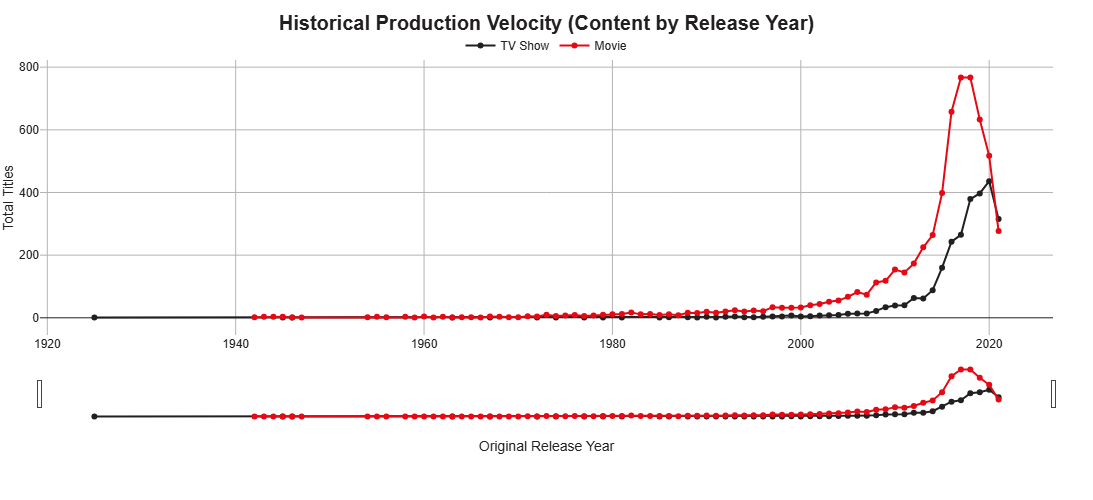

In [24]:
# ============================================================
# CHART 4 — HISTORICAL PRODUCTION VELOCITY (CONTENT BY RELEASE YEAR)
# ============================================================

# 1. Prepare Data: Count titles by release year and format type
release_counts = df.groupby(['release_year', 'type']).size().reset_index(name='count')

# 2. Build the Plotly Figure (Line Chart to avoid stacked axis distortion)
fig4 = px.line(
    release_counts,
    x='release_year',
    y='count',
    color='type',
    markers=True,                                    # <--- Added this line
    color_discrete_map={'Movie': NETFLIX_COLORS['red'], 'TV Show': NETFLIX_COLORS['black']},
    labels={'release_year': 'Original Release Year', 'count': 'Total Titles', 'type': 'Content Type'}
)
# 3. Apply Netflix-themed Layout Formatting (Centered Canvas & Title)
fig4.update_layout(
    height=500,
    title=dict(
        text='<b>Historical Production Velocity (Content by Release Year)</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    xaxis=dict(
        showgrid=True, 
        gridcolor=NETFLIX_COLORS['light_gray'], 
        gridwidth=1, 
        zeroline=True, 
        zerolinecolor=NETFLIX_COLORS['black']
    ),
    yaxis=dict(
        showgrid=True, 
        gridcolor=NETFLIX_COLORS['light_gray'], 
        gridwidth=1, 
        zeroline=True, 
        zerolinecolor=NETFLIX_COLORS['black']
    ),
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1,                                      # Pushed down to clear X-axis labels
        xanchor='center',
        x=0.5,
        title=None,
        font=dict(size=12, color=NETFLIX_COLORS['black'])
    ),
    margin=dict(t=60, b=80, l=40, r=40)              # Increased bottom margin for the legend
)

# 4. Customizing hover details and adding interactive timeline slider
fig4.update_traces(hovertemplate="<b>%{x}</b><br>Volume: %{y:,}<extra></extra>")
fig4.update_xaxes(rangeslider_visible=True)

# 5. Display the Chart
fig4.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 5 — PLATFORM INGESTION TRAJECTORY (TITLES ADDED BY YEAR)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Grouped Bar Chart (Plotly `px.bar` with `barmode='group'`).
* **Engineered & Core Features:** `year_added`, `type`.
* **Visual Rationale:** Replacing stacked areas with side-by-side grouped bars grounds both Movies and TV Shows at a shared zero-baseline on the Y-axis, eliminating visual distortion. It also breaks visual fatigue after Chart 4's continuous line plot, distinguishing long-term cinema trends from annual operational acquisition reports.
* **Color Palette Mapping:**
  * `Movie`: Primary Netflix Red (`#E50914`)
  * `TV Show`: Netflix Dark Near-Black (`#221F1F`)

#### ❓ BUSINESS QUESTION
In which years did Netflix execute its most aggressive catalog scaling, and how did annual acquisition priorities between feature films and television series evolve over time?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** Annual additions were modest through 2015, followed by an aggressive volume expansion from 2016 to 2019 (peaking at over 2,000 titles added in 2019 alone). Movie acquisitions drove the bulk of this volume surge, while TV Show additions expanded at a steadier, controlled rate.
* **Commercial Implication:** The 2016–2019 surge reflects Netflix's global footprint expansion, where bulk licensing of films was used to quickly establish regional catalog depth. The post-2019 plateau and slight dip signal a shift from unconstrained volume backfill toward curated, higher-margin original productions.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why use a grouped bar chart here instead of an area chart or another line plot?"
* **Strategic Driver:** "A continuous line chart in Chart 4 captured historical cinema across nearly a century. Ingestions (`year_added`), however, occur in discrete calendar-year licensing cycles within a compact window (2008–2021). A grouped bar chart treats years as discrete reporting periods and gives both Movies and TV Shows their own baseline, preventing the misreadings common to stacked visuals."

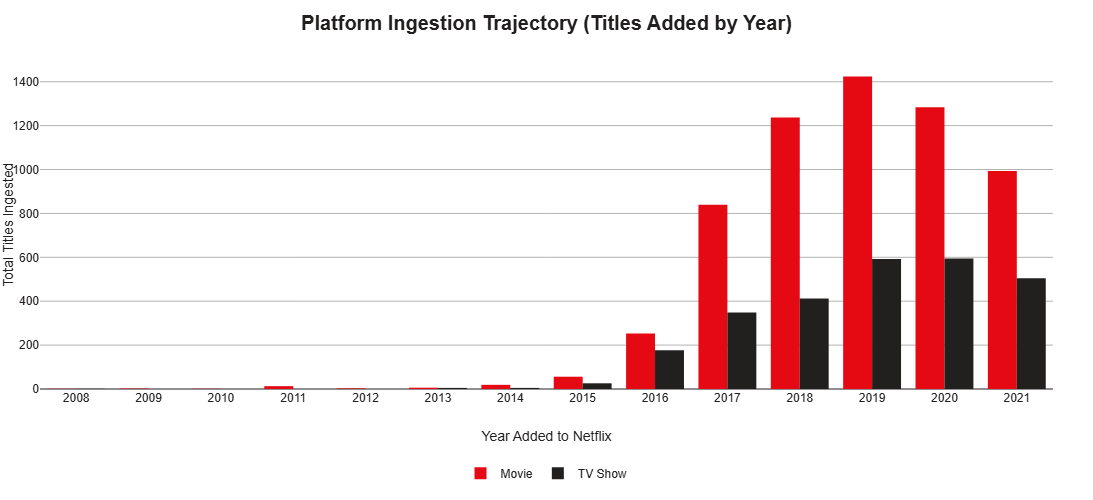

In [25]:
# ============================================================
# CHART 5 — PLATFORM INGESTION TRAJECTORY (TITLES ADDED BY YEAR)
# ============================================================

# 1. Prepare Data: Count titles acquired by year added and format type
ingestion_counts = df.groupby(['year_added', 'type']).size().reset_index(name='count')

# 2. Build the Plotly Figure (Grouped Bar Chart for discrete annual volume)
fig5 = px.bar(
    ingestion_counts,
    x='year_added',
    y='count',
    color='type',
    barmode='group',                                 # Side-by-side bars fix the Y-axis scaling issue
    color_discrete_map={'Movie': NETFLIX_COLORS['red'], 'TV Show': NETFLIX_COLORS['black']},
    labels={'year_added': 'Year Added to Netflix', 'count': 'Total Titles Ingested', 'type': 'Content Type'}
)

# 3. Apply Netflix-themed Layout Formatting (Centered Canvas & Title)
fig5.update_layout(
    height=500,
    title=dict(
        text='<b>Platform Ingestion Trajectory (Titles Added by Year)</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    xaxis=dict(
        showgrid=False,                              # Clean X-axis for bar charts
        zeroline=True, 
        zerolinecolor=NETFLIX_COLORS['black'],
        tickmode='linear'                            # Forces every year to display as a distinct label
    ),
    yaxis=dict(
        showgrid=True, 
        gridcolor=NETFLIX_COLORS['light_gray'], 
        gridwidth=1, 
        zeroline=True, 
        zerolinecolor=NETFLIX_COLORS['black']
    ),
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.3,
        xanchor='center',
        x=0.5,
        title=None,
        font=dict(size=12, color=NETFLIX_COLORS['black'])
    ),
    margin=dict(t=60, b=40, l=40, r=40)
)

# 4. Customizing hover details and timeline slider
fig5.update_traces(hovertemplate="<b>%{x}</b><br>Ingested Volume: %{y:,}<extra></extra>")

# 5. Display the Chart
fig5.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 6 — LIBRARY FRESHNESS MATRIX (RELEASE VS. INGESTION)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Bubble Matrix / Interactive Scatter (Plotly `px.scatter`).
* **Engineered & Core Features:** `release_year` (X-axis), `year_added` (Y-axis), `count` (Size & Color).
* **Visual Rationale:** Plotting two integer-based timelines against each other using a standard scatter plot results in severe overplotting. A Bubble Matrix solves this by pre-aggregating overlapping coordinates and dual-encoding the volume to both bubble size and color intensity. This creates a clean, proportional heat-map effect without the blocky visual weight of a traditional square grid.
* **Color Palette Mapping:** A custom continuous Netflix gradient (`#221F1F` $\rightarrow$ `#B20710` $\rightarrow$ `#E50914`).

#### ❓ BUSINESS QUESTION
Is Netflix's strategy focused on day-and-date fresh releases (Originals and immediate exclusives), or is the platform primarily backfilling its library with older, syndicated legacy content?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The matrix reveals a massive, glowing cluster of large bubbles along the "diagonal" (where `year_added` equals `release_year`), meaning the vast majority of titles arrive on Netflix the exact same year they are produced. 
* **Commercial Implication:** The dense diagonal validates that Netflix has successfully transitioned from a secondary syndication window (hosting old movies) to a primary premiere destination. The modern value proposition relies heavily on recency and exclusivity rather than a deep archival back catalog.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you choose a Bubble Matrix instead of a standard scatter plot or a traditional heatmap?"
* **Strategic Driver:** "With thousands of titles mapped across whole-number years, a standard scatter plot suffers from severe coordinate overlap, hiding the true volume. A traditional square heatmap solves the math but looks blocky and rigid. By pre-aggregating the data and using a Bubble Matrix, I dual-encoded the volume to both size and color. This mathematically represents the exact density of the timeline while maintaining a clean, modern aesthetic."

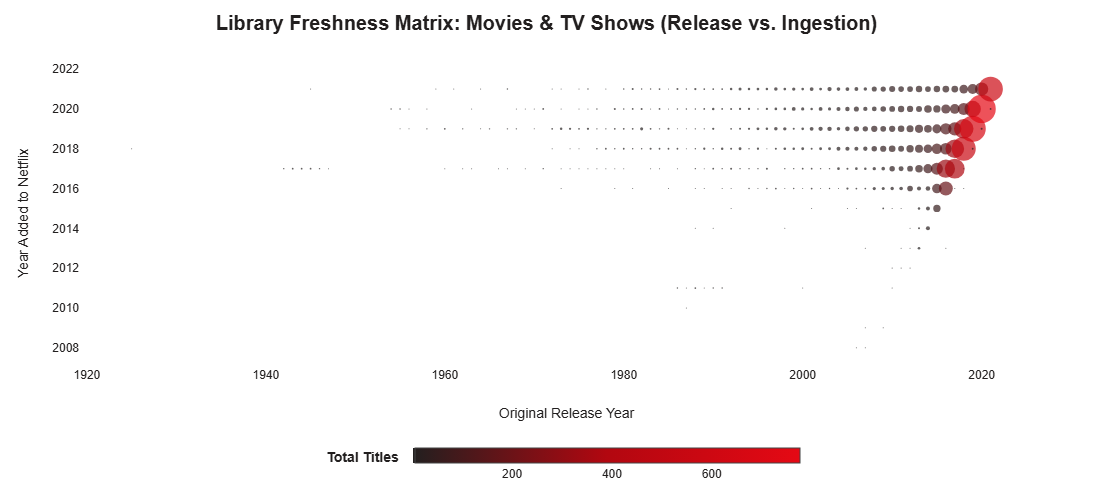

In [26]:
# ============================================================
# CHART 6 — LIBRARY FRESHNESS MATRIX (RELEASE VS. INGESTION)
# ============================================================

# 1. Prepare Data: Aggregate the counts for overlapping years to create a bubble matrix
heat_counts = df.groupby(['release_year', 'year_added']).size().reset_index(name='count')

# 2. Custom Continuous Scale 

netflix_heatmap_scale = [
    [0.0, '#221F1F'],                     
    [0.5, '#B20710'],                     
    [1.0, '#E50914']                      
]

# 3. Build the Plotly Figure (Bubble Matrix using Scatter)
fig6 = px.scatter(
    heat_counts,
    x='release_year',
    y='year_added',
    size='count',                                    # Circles grow based on volume
    color='count',                                   # Circles darken based on volume
    color_continuous_scale=netflix_heatmap_scale,
    labels={'release_year': 'Original Release Year', 'year_added': 'Year Added to Netflix', 'count': 'Total Titles'}
)

# 4. Apply Netflix-themed Layout Formatting (Centered Canvas, Title, & Colorbar)
fig6.update_layout(
    height=500,
    title=dict(
        text='<b>Library Freshness Matrix: Movies & TV Shows (Release vs. Ingestion)</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    xaxis=dict(
        showgrid=False,                              
        zeroline=False
    ),
    yaxis=dict(
        showgrid=False, 
        zeroline=False,
        title_standoff=20                            # Pushes the Y-axis title away from the numbers
    ),
    margin=dict(t=60, b=100, l=80, r=40),            # Increased bottom and left margins
    
    # Position the heat scale lower to prevent X-axis overlap
    coloraxis_colorbar=dict(
        title=dict(text="<b>Total Titles</b>", font=dict(color=NETFLIX_COLORS['black'])),
        orientation='h',
        yanchor='bottom',
        y=-0.4,                                      # Pushed further down
        xanchor='center',
        x=0.5,
        thickness=15,
        len=0.5
    )
)

# 5. Customizing hover details
fig6.update_traces(
    marker=dict(line=dict(width=0)),                 # Removes border from bubbles for a cleaner look
    hovertemplate="<b>Release Year:</b> %{x}<br><b>Year Added:</b> %{y}<br><b>Volume:</b> %{marker.size}<extra></extra>"
)

# 6. Display the Chart
fig6.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 7 — CUMULATIVE ACQUISITION LAG (FRESHNESS BY PERCENTAGE)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Cumulative Distribution Function (Plotly `px.ecdf`).
* **Engineered & Core Features:** `acquisition_lag` (Calculated as `year_added` - `release_year`), `type`.
* **Visual Rationale:** Replaces a standard overlapping histogram. Histograms focus on absolute counts and become visually muddy when comparing categories with vastly different volumes and outlier tails. An ECDF translates those counts into a 0-100% trajectory, allowing for a direct, "apples-to-apples" comparison of catalog freshness across formats.
* **Color Palette Mapping:**
  * `Movie`: Primary Netflix Red (`#E50914`)
  * `TV Show`: Netflix Dark Near-Black (`#221F1F`)

#### ❓ BUSINESS QUESTION
At what velocity does Netflix acquire content post-release, and how does the "freshness" standard differ strategically between Movies and TV Shows?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The TV Show trajectory is remarkably steep, breaching the 80% cumulative mark at just 3 years of lag. Movies follow a much slower curve, taking 8 years to reach that exact same 80% threshold. 
* **Commercial Implication:** This mathematically proves a bifurcated licensing strategy. TV Shows are treated almost strictly as immediate, contemporary assets (driven by Originals and day-and-date broadcast licensing). Movies serve a dual purpose: acting as fresh premiere attractions while simultaneously relying on a massive "long tail" of older syndicated films to artificially pad the catalog's depth.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you use an ECDF instead of a standard histogram to show distribution?"
* **Strategic Driver:** "A histogram visualizes raw volume, which gets chaotic when one category has a massive long tail of outliers. An ECDF converts that data into a 'Service Level' metric. Business stakeholders don't ask 'How many titles have a 3-year lag?'; they ask 'What percentage of our catalog is less than 3 years old?' The ECDF answers that exact executive question instantly."

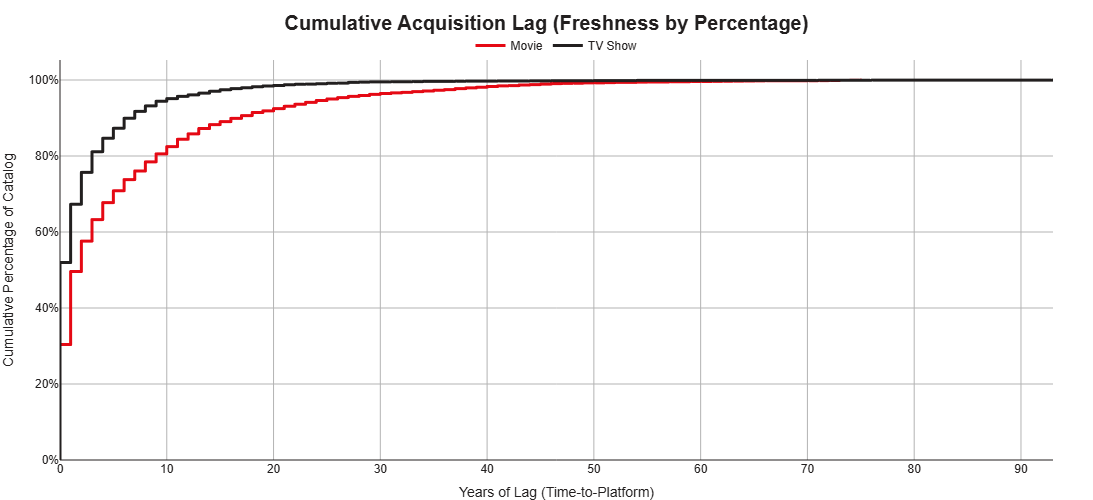

In [27]:
# ============================================================
# CHART 7 — CUMULATIVE ACQUISITION LAG (TIME-TO-PLATFORM)
# ============================================================

# 1. Prepare Data: Engineer the 'acquisition_lag' feature
if 'acquisition_lag' not in df.columns:
    df['acquisition_lag'] = df['year_added'] - df['release_year']

# Filter out negative lags and nulls
lag_df = df[df['acquisition_lag'] >= 0].dropna(subset=['acquisition_lag'])

# 2. Build the Plotly Figure (ECDF - Empirical Cumulative Distribution Function)
fig7 = px.ecdf(
    lag_df,
    x='acquisition_lag',
    color='type',
    color_discrete_map={'Movie': NETFLIX_COLORS['red'], 'TV Show': NETFLIX_COLORS['black']},
    labels={'acquisition_lag': 'Years Between Release and Netflix Debut', 'type': 'Content Type'}
)

# 3. Apply Netflix-themed Layout Formatting
fig7.update_layout(
    height=500,
    title=dict(
        text='<b>Cumulative Acquisition Lag (Freshness by Percentage)</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    xaxis=dict(
        title_text='Years of Lag (Time-to-Platform)',
        showgrid=True, 
        gridcolor=NETFLIX_COLORS['light_gray'], 
        zeroline=True, 
        zerolinecolor=NETFLIX_COLORS['black']
    ),
    yaxis=dict(
        title_text='Cumulative Percentage of Catalog',
        title_standoff=20,
        tickformat='.0%',                            # Formats the Y-axis as 0%, 20%, 40%, etc.
        showgrid=True, 
        gridcolor=NETFLIX_COLORS['light_gray'], 
        zeroline=True, 
        zerolinecolor=NETFLIX_COLORS['black']
    ),
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.0,
        xanchor='center',
        x=0.5,
        title=None,
        font=dict(size=12, color=NETFLIX_COLORS['black'])
    ),
    margin=dict(t=60, b=40, l=60, r=40)
)

# 4. Customizing hover details and line thickness
fig7.update_traces(
    line=dict(width=3),                              # Thicker lines for a premium dashboard feel
    hovertemplate="<b>Lag Time:</b> %{x} years<br><b>Cumulative Catalog:</b> %{y:.1%}<extra></extra>"
)

# 5. Display the Chart
fig7.show()

# ============================================================
# 🌍 SECTION C: GEOGRAPHICAL & GLOBAL CONTENT STRATEGY
# ============================================================

### 📌 SECTION GOAL & STRATEGIC CONTEXT
Analyze the geographic footprint of Netflix's content production to evaluate its transition from a US-centric platform to a truly global streaming network. This section maps out the international production hubs, measuring the balance between domestic dominance and regional localization efforts (e.g., international expansion into markets like the UK, India, South Korea, and Japan).

### 🔑 KEY BUSINESS QUESTIONS ADDRESSED
* Which countries serve as the foundational production hubs for Netflix's catalog?
* How heavily does Netflix rely on the United States ecosystem versus international markets?
* Are there regional production biases? (e.g., Do certain countries index heavily toward producing feature films while others specialize in multi-season television series?)
* How geographically diversified is the platform's overall offering to cater to a global subscriber base?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 8 — TOP 15 PRODUCTION COUNTRIES (VOLUME & FORMAT PREFERENCE)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Horizontal Stacked Bar Chart (Plotly `px.bar`).
* **Engineered & Core Features:** `country` (exploded/un-nested), `type`.
* **Visual Rationale:** A horizontal bar chart is the most effective way to rank categories with long text labels (country names). By stacking the bars by `type`, we instantly communicate two metrics at once: the total production volume of the country (the total length of the bar) and the regional format bias (the ratio of red to black inside the bar).
* **Color Palette Mapping:**
  * `Movie`: Primary Netflix Red (`#E50914`)
  * `TV Show`: Netflix Dark Near-Black (`#221F1F`)

#### ❓ BUSINESS QUESTION
Which countries dominate Netflix's global supply chain, and do specific regions exhibit a bias toward producing feature films versus television series?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The United States completely dominates total volume, holding a massive lead over all other nations combined. However, looking at the format ratios reveals deep regional biases: India indexes almost exclusively in feature films (driven by Bollywood acquisition), while countries like South Korea and Japan exhibit a much higher concentration of TV Shows (driven by K-Dramas and Anime).
* **Commercial Implication:** Netflix does not apply a "one-size-fits-all" global acquisition strategy. It highly localizes its catalog to match regional industry strengths—buying bulk cinema in India, while investing heavily in episodic series in East Asia.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "You are analyzing geographic data. Why did you use a simple horizontal bar chart instead of a world map (Choropleth)?"
* **Strategic Driver:** "World maps are visually impressive but analytically weak for this specific dataset. Because the US volume is so aggressively high, a color-coded map would just show a dark red North America and a pale rest of the world, making it impossible to distinguish the rank of the 2nd through 10th countries. A horizontal bar chart allows for exact, ranked volume comparisons and cleanly supports the Movie vs. TV Show format split, which a map cannot easily do."

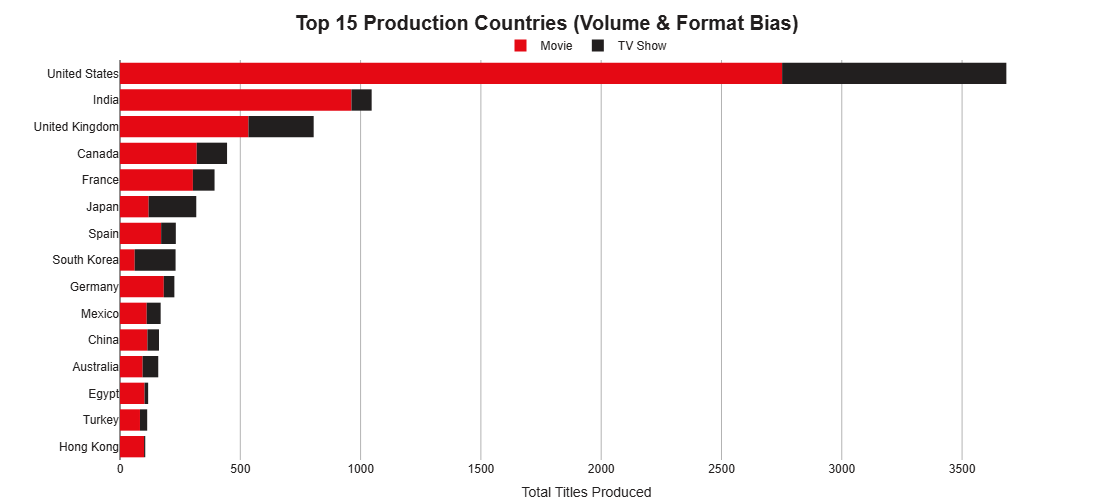

In [28]:
# ============================================================
# CHART 8 — TOP 15 PRODUCTION COUNTRIES (VOLUME & FORMAT PREFERENCE)
# ============================================================
# 1. Prepare Data using engineered 'country_list'
country_df = df.explode('country_list').dropna(subset=['country_list'])

# --- ADD THESE TWO LINES HERE ---
country_df = country_df[~country_df['country_list'].astype(str).str.lower().str.contains('unknown')]
country_df = country_df[country_df['country_list'].astype(str).str.strip() != '']

# Group by country and type, then count total titles
country_counts = country_df.groupby(['country_list', 'type']).size().reset_index(name='count')

# Find Top 15 countries
top_15_countries = country_df['country_list'].value_counts().head(15).index
top_15_df = country_counts[country_counts['country_list'].isin(top_15_countries)]

# 2. Build the Plotly Figure (Horizontal Stacked Bar Chart)
fig8 = px.bar(
    top_15_df,
    x='count',
    y='country_list',                                
    color='type',
    orientation='h',
    color_discrete_map={'Movie': NETFLIX_COLORS['red'], 'TV Show': NETFLIX_COLORS['black']},
    labels={'count': 'Total Titles Produced', 'country_list': 'Production Country', 'type': 'Content Type'},
    category_orders={'country_list': top_15_countries[::1]}  
)
# 3. Apply Netflix-themed Layout Formatting
fig8.update_layout(
    height=500,                                      
    title=dict(
        text='<b>Top 15 Production Countries (Volume & Format Bias)</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    xaxis=dict(
        showgrid=True, 
        gridcolor=NETFLIX_COLORS['light_gray'], 
        zeroline=True, 
        zerolinecolor=NETFLIX_COLORS['black']
    ),
    yaxis=dict(
        showgrid=False,                              # No horizontal gridlines needed for bar charts
        title_text=''                                # Removed Y-axis title since country names are self-explanatory
    ),
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.0,
        xanchor='center',
        x=0.5,
        title=None,
        font=dict(size=12, color=NETFLIX_COLORS['black'])
    ),
    margin=dict(t=60, b=40, l=120, r=40)             # Increased left margin to ensure longer country names fit
)

# 4. Customizing hover details
fig8.update_traces(
    hovertemplate="<b>%{y}</b><br>Volume: %{x}<extra></extra>"
)

# 5. Display the Chart
fig8.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 9 — GLOBAL CONTENT PRODUCTION FOOTPRINT (CHOROPLETH)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** 2D Choropleth Map (Plotly `px.choropleth`).
* **Engineered & Core Features:** `country_list` (exploded), `count` (Total Titles).
* **Visual Rationale:** A choropleth map visually grounds the dataset in physical geography, immediately answering the question of Netflix's global reach. To prevent the United States (with ~3,600+ titles) from washing out the rest of the world (where most countries have under 100), we utilize a logarithmic or binned color scale. This ensures that major international hubs (like the UK, India, and South Korea) remain visible and distinct, rather than fading into a uniform "low volume" background color.
* **Color Palette Mapping:** A custom continuous Netflix gradient (`#F5F5F1` $\rightarrow$ `#F94A4D` $\rightarrow$ `NETFLIX_COLORS['black']`).

#### ❓ BUSINESS QUESTION
How geographically diversified is Netflix's content supply chain, and which international regions serve as the primary production hubs outside of North America?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** While the United States remains the undisputed center of production, the map reveals distinct, highly active regional clusters: Europe (led by the UK, France, and Spain) and Asia (led by India, Japan, and South Korea). Significant portions of Africa, the Middle East, and Eastern Europe remain "cold spots" with negligible production volume.
* **Commercial Implication:** Netflix has successfully established major international footholds, but its production strategy is highly concentrated in a few key "super-regions" rather than being evenly distributed globally. This targeted localization strategy focuses on high-subscriber-growth markets with established local film industries.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why didn't you use a standard linear color scale for this map, or a 3D globe visualization?"
* **Strategic Driver:** "A 3D globe looks flashy but is analytically poor because it hides half the data at any given time, requiring user interaction just to see the full picture. Regarding the color scale: if I used a standard linear scale, the extreme volume of the US (~3,600 titles) would force every other country into the lowest color bracket, rendering the map useless for international analysis. Applying a logarithmic scale normalizes the massive variance, allowing us to clearly distinguish a mid-tier hub like Spain from a low-tier country like New Zealand."

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6468\2308148721.py:27: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



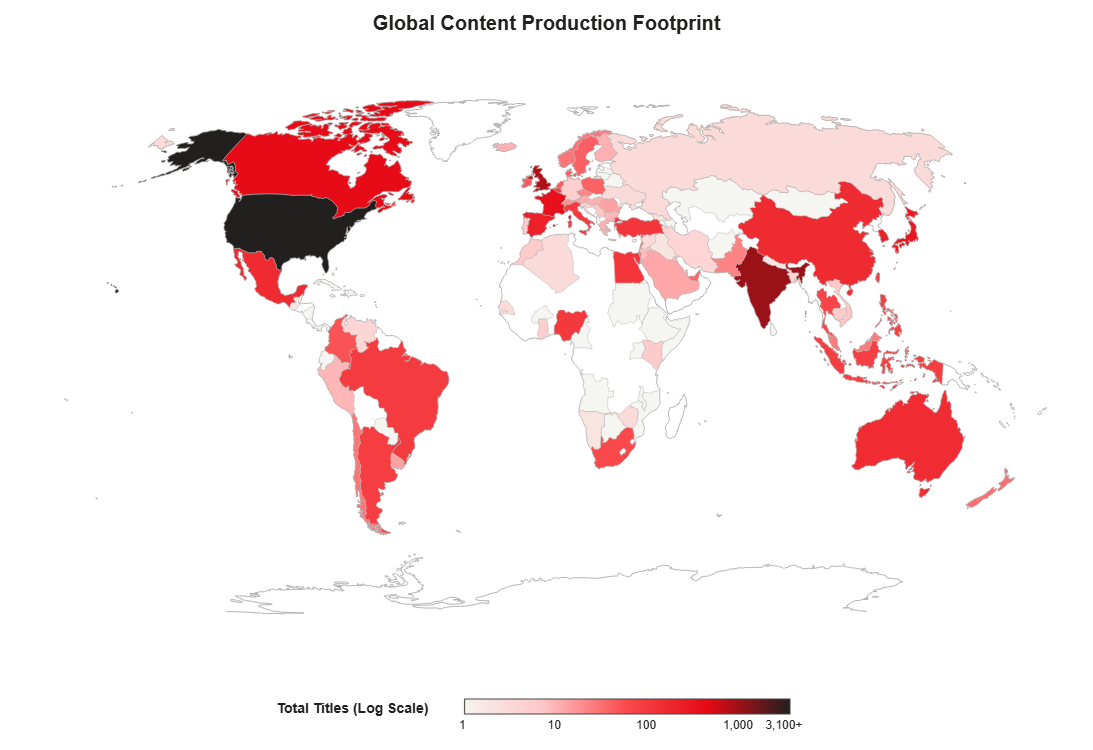

In [29]:
# ============================================================
# CHART 9 — GLOBAL CONTENT PRODUCTION FOOTPRINT (CHOROPLETH)
# ============================================================

# 1. Prepare Data: Explode the engineered 'country_list' and count titles per country
country_df = df.explode('country_list').dropna(subset=['country_list'])
# Remove any accidental empty strings from parsing
country_df = country_df[country_df['country_list'].str.strip() != ''] 

country_counts = country_df.groupby('country_list').size().reset_index(name='count')

# Engineer a Logarithmic feature specifically for the color scale 
# This prevents the US (~3,600) from washing out countries like the UK (~800) or Spain (~200)
country_counts['log_count'] = np.log10(country_counts['count'])

# Custom Continuous Scale (Light Gray -> Pink -> Brand Red -> Black)
# This creates harder contrast between low-volume (gray/pink), mid-volume (red), and the US (black)
netflix_map_scale = [
    [0.0, '#F5F5F1'],                     # Very light neutral for 1-9 titles
    [0.25, '#FFC5C6'],                    # Light pink for ~10-50 titles
    [0.5, '#F94A4D'],                     # Bright red for ~100 titles
    [0.75, NETFLIX_COLORS['red']],        # Brand Red for ~1,000 titles (Major Hubs)
    [1.0, NETFLIX_COLORS['black']]        # Near-Black for 3,000+ titles (US Mega Hub)
]
# 2. Build the Plotly Figure (2D Choropleth)
# Using locationmode='country names' allows Plotly to natively match standard text names
fig9 = px.choropleth(
    country_counts,
    locations='country_list',
    locationmode='country names',
    color='log_count',
    color_continuous_scale=netflix_map_scale,
    hover_name='country_list',
    custom_data=['count']                            # Pass actual counts to the hover template
)

# 3. Apply Netflix-themed Layout Formatting
fig9.update_layout(
    height=750,
    title=dict(
        text='<b>Global Content Production Footprint</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    
    # Configure the map projection (Natural Earth is the industry standard for flat maps)
    geo=dict(
        showframe=False,                             # Removes the black box around the map
        showcoastlines=True,
        coastlinecolor=NETFLIX_COLORS['light_gray'],
        projection_type='natural earth',             # Reduces the geographic distortion of polar landmasses
        bgcolor='#FFFFFF',
        showocean=False,
        showlakes=False
    ),
    margin=dict(t=60, b=80, l=40, r=40),
    
    # Format the colorbar to display human-readable numbers instead of log values
    coloraxis_colorbar=dict(
        title=dict(text="<b>Total Titles (Log Scale)</b>", font=dict(color=NETFLIX_COLORS['black'])),
        orientation='h',
        yanchor='bottom',
        y=-0.15,
        xanchor='center',
        x=0.5,
        thickness=15,
        len=0.5,
        tickvals=[0, 1, 2, 3, 3.5],                  # Map the log scale ticks...
        ticktext=['1', '10', '100', '1,000', '3,100+'] # ...to actual title volume labels
    )
)

# 4. Customizing hover details to show the raw count, hiding the backend log math
fig9.update_traces(
    hovertemplate="<b>%{hovertext}</b><br>Total Titles: %{customdata[0]:,}<extra></extra>",
    marker_line_width=0.5,                           # Thin borders between countries
    marker_line_color=NETFLIX_COLORS['light_gray']
)

# 5. Display the Chart
fig9.show()

# ============================================================
# 🎭 SECTION D: GENRE INTELLIGENCE & CATEGORY MIX
# ============================================================

### 📌 SECTION GOAL & STRATEGIC CONTEXT
Analyze the thematic composition of the Netflix catalog. This section deconstructs how titles are classified, identifying the core genres that drive audience engagement and revealing how Netflix tailors its categorical investments to specific regions and formats.

### 🔑 KEY BUSINESS QUESTIONS ADDRESSED
* What are the foundational pillars of Netflix's content library?
* How does cultural geography dictate genre production (e.g., Anime in Japan vs. Stand-Up in the US)?
* Which genres are prioritized for Movies versus TV Shows?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 10 — THE GENRE LANDSCAPE (PORTFOLIO TREEMAP)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Treemap (Plotly `px.treemap`).
* **Engineered & Core Features:** `genre_list` (exploded), `count` (Total Volume).
* **Visual Rationale:** We actively chose to skip a standard ranked bar chart. A Treemap translates raw list rankings into a "portfolio allocation" perspective. By mapping the total title count to the physical area of each rectangle, stakeholders can instantly *feel* the weight of the platform's core genres versus its niche offerings in a single, compact, square visual footprint. 
* **Color Palette Mapping:** A continuous Netflix heat gradient based on volume (from a Netflix Black `#221F1F` for smaller niche genres up to the Netflix Red `#E50914` for the massive pillars).

#### ❓ BUSINESS QUESTION
What is the macro-composition of Netflix's content portfolio, and which thematic categories consume the most catalog "shelf space"?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The visual real estate is overwhelmingly dominated by three massive blocks: *International Movies*, *Dramas*, and *Comedies*. These foundational pillars form the bedrock of the catalog, physically pushing niche categories (like Sci-Fi, Horror, or Anime) to the outer margins.
* **Commercial Implication:** Netflix's core acquisition strategy is highly risk-averse regarding volume. While they aggressively market expensive niche hits (like *Stranger Things* for Sci-Fi), the actual vault is overwhelmingly stocked with universal, highly translatable themes and localized global cinema to ensure there is a baseline offering for every global demographic.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you use a Treemap here instead of a standard Top 10 horizontal bar chart?"
* **Strategic Driver:** "A bar chart is great for a race, but poor for showing market share across 20+ categories. A Treemap acts like a financial portfolio chart—it shows exactly how Netflix's genre 'real estate' is partitioned. Furthermore, I already used a horizontal bar chart to analyze country volume in Section C; repeating that layout here would cause visual fatigue. The Treemap delivers the exact same hierarchy but in a much more engaging, macro-level format."

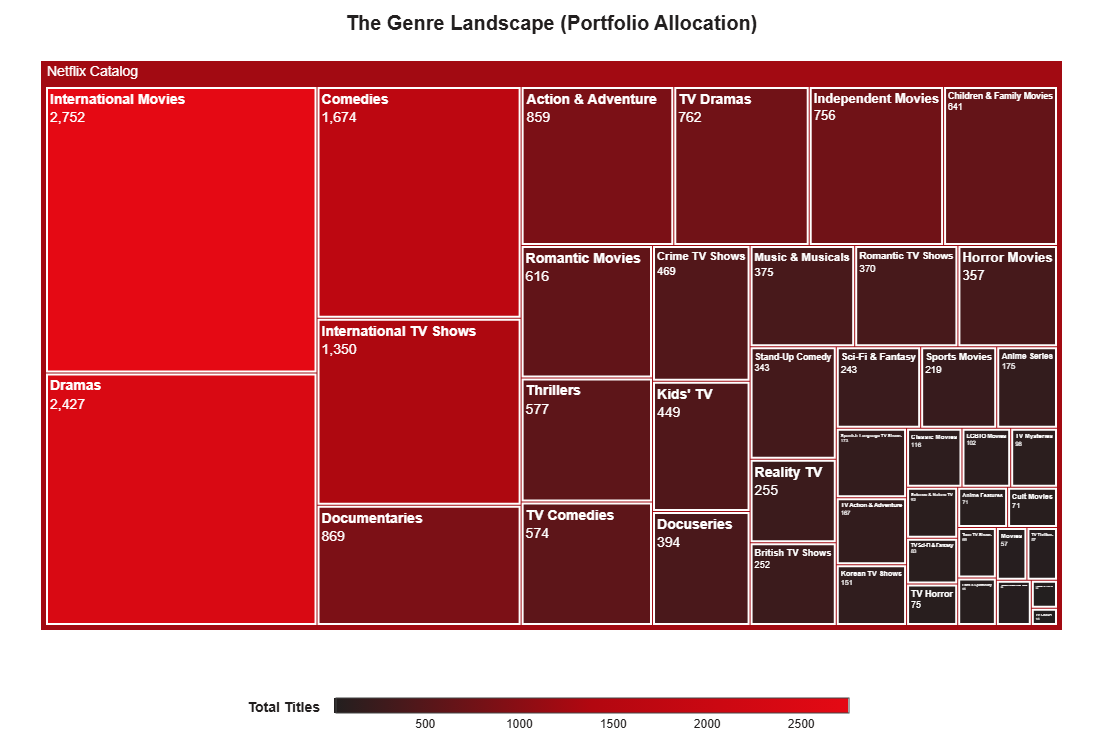

In [30]:
# ============================================================
# CHART 10 — THE GENRE LANDSCAPE (PORTFOLIO TREEMAP)
# ============================================================

# 1. Prepare Data: Explode the engineered 'genre_list' and count titles per genre
genre_df = df.explode('genre_list').dropna(subset=['genre_list'])
# Remove any accidental empty strings from parsing
genre_df = genre_df[genre_df['genre_list'].str.strip() != '']

# Group by genre and get the total count
genre_counts = genre_df.groupby('genre_list').size().reset_index(name='count')

# 2. Define the Custom Continuous Netflix Color Scale
# Translates volume into heat (Netflix Black -> Dark Red -> Bright Brand Red)
netflix_treemap_scale = [
    [0.0, '#221F1F'],                     
    [0.5, '#B20710'],                     
    [1.0, '#E50914']                      
]

# 3. Build the Plotly Figure (Treemap)
fig10 = px.treemap(
    genre_counts,
    path=[px.Constant("Netflix Catalog"), 'genre_list'],  # Creates a master root node
    values='count',
    color='count',
    color_continuous_scale=netflix_treemap_scale,
    custom_data=['count']
)

# 4. Apply Netflix-themed Layout Formatting
fig10.update_layout(
    height=750,
    title=dict(
        text='<b>The Genre Landscape (Portfolio Allocation)</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    margin=dict(t=60, b=100, l=40, r=40), # Increased bottom margin (b=100) to fit the legend
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    
    # Format the colorbar for horizontal bottom placement
    coloraxis_colorbar=dict(
        title=dict(text="<b>Total Titles</b>", font=dict(color=NETFLIX_COLORS['black'])),
        orientation="h",       # Makes the legend horizontal
        thickness=15,
        len=0.6,
        yanchor="top",
        y=-0.1,                # Pushes it below the chart canvas
        xanchor="center",
        x=0.5
    )
)
# 5. Customizing hover details, text labels, and borders
fig10.update_traces(
    # Changed %{customdata[0]:,} to %{value:,} to fix the root node math
    hovertemplate="<b>%{label}</b><br>Total Titles: %{value:,}<extra></extra>",
    texttemplate="<b>%{label}</b><br>%{value:,}",
    textfont=dict(size=14),                          
    marker_line_width=2,                             
    marker_line_color='#FFFFFF'                      
)
# 6. Display the Chart
fig10.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 11 — GENRE DOMINANCE BY FORMAT (BUTTERFLY CHART)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** 100% Diverging Bar Chart ("Butterfly Chart") (Plotly `px.bar` with `barmode='relative'` and negative values for Movies).
* **Engineered & Core Features:** `root_genre` (Engineered), `type`, percentage distribution.
* **Data Engineering Pivot (The Root Genre):** 
  * *The Problem:* Netflix's raw `listed_in` categories are inherently format-biased (e.g., "TV Comedies" vs. "Comedies", "Docuseries" vs. "Documentaries"). If we plot this raw data, the chart simply tells us that "TV Comedies" are 100% TV shows—a useless tautology.
  * *The Solution:* We engineer a `root_genre` column by stripping format-specific prefixes and grouping synonymous terms (e.g., mapping both "TV Comedies" and "Comedies" to a single "Comedy" root). This normalizes the data, allowing us to see the *true* format split within a thematic category.
* **Visual Rationale:** The Butterfly Chart physically splits the formats along a central axis (Movies to the left, TV to the right). By converting absolute counts into a 100% distribution for each root genre, we eliminate the volume skew. This makes it instantly clear which direction a genre's strategy "pulls," regardless of its total size.
* **Color Palette Mapping:**
  * `Movie` (Left): Primary Netflix Red (`#E50914`)
  * `TV Show` (Right): Netflix Dark Near-Black (`#221F1F`)

#### ❓ BUSINESS QUESTION
Once thematic overlap is normalized, which content categories translate primarily into feature films versus recurring episodic series?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The normalized data reveals stark format biases that were previously hidden. For instance, **Stand-Up Comedy** and **Documentaries** are overwhelmingly biased toward feature-length formats (pulling heavily to the left). Conversely, **Crime**, **Kids' Programming**, and **Reality/Docuseries** dominate the episodic TV side (pulling heavily to the right).
* **Commercial Implication:** Netflix understands that certain themes are better suited for specific retention strategies. Stand-up specials act as quick, impactful subscriber acquisition events (Movies), while Crime and Kids' content are designed as "bingeable," multi-hour retention engines (TV Shows).

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you create this `root_genre` column instead of just using the raw data categories, and why use a Butterfly Chart instead of a stacked bar?"
* **Strategic Driver:** "If I used the raw categories, the chart would be meaningless because Netflix pre-tags TV shows and movies differently (e.g., 'TV Comedies'). By engineering a normalized `root_genre`, I removed the data entry bias to reveal the actual strategic format split. I chose the Butterfly Chart because it visually divides the formats across a zero-axis, making the 'pull' of each genre instantly readable, whereas a stacked bar chart would force the viewer to constantly reference the legend."

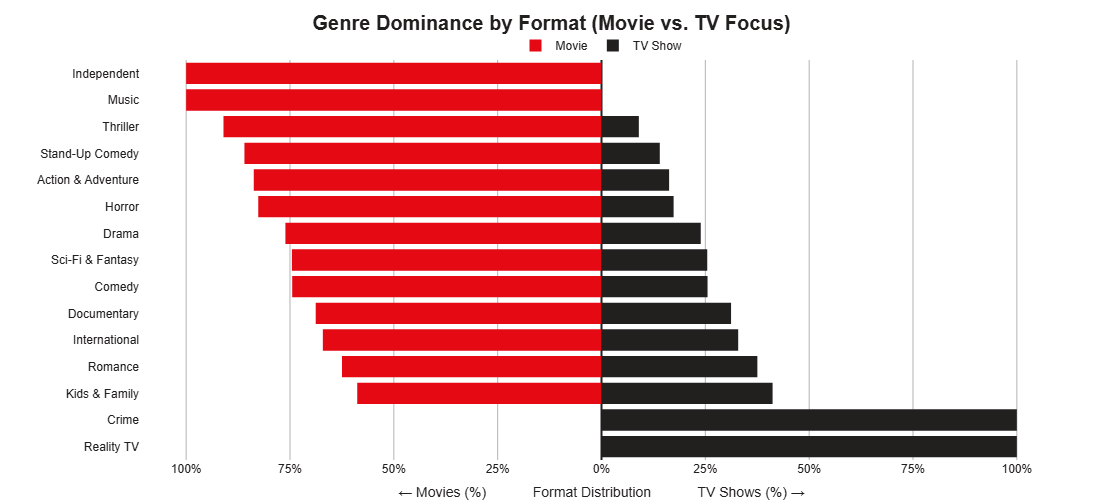

In [31]:
# ============================================================
# CHART 11 — GENRE DOMINANCE BY FORMAT (BUTTERFLY CHART)
# ============================================================

# 1. Prepare Data: Explode the engineered 'genre_list'
genre_df = df.explode('genre_list').dropna(subset=['genre_list'])
genre_df = genre_df[genre_df['genre_list'].str.strip() != '']

# 2. Data Engineering Pivot: Engineer the 'root_genre' to remove format bias
def get_root_genre(g):
    g = g.strip()
    if 'Stand-Up' in g: return 'Stand-Up Comedy'
    if 'Comed' in g: return 'Comedy'
    if 'Action' in g: return 'Action & Adventure'
    if 'Docum' in g or 'Docuseries' in g: return 'Documentary'
    if 'Sci-Fi' in g or 'Fantasy' in g: return 'Sci-Fi & Fantasy'
    if 'Crime' in g: return 'Crime'
    if 'Kid' in g or 'Children' in g: return 'Kids & Family'
    if 'Horror' in g: return 'Horror'
    if 'Thriller' in g: return 'Thriller'
    if 'Roman' in g: return 'Romance'
    if 'Drama' in g: return 'Drama'
    if 'Anime' in g: return 'Anime'
    if 'Music' in g: return 'Music'
    if 'Reality' in g: return 'Reality TV'
    # Fallback to strip obvious format words for anything else
    return g.replace(' Movies', '').replace(' TV Shows', '').replace(' Series', '').replace('TV ', '').strip()

genre_df['root_genre'] = genre_df['genre_list'].apply(get_root_genre)

# 3. Group by root_genre and type, then count total titles
counts_df = genre_df.groupby(['root_genre', 'type']).size().reset_index(name='count')

# Filter for the Top 15 root genres by total volume to keep the chart clean
top_15_genres = genre_df['root_genre'].value_counts().head(15).index
counts_df = counts_df[counts_df['root_genre'].isin(top_15_genres)]

# 4. Calculate Percentage Distribution
total_per_genre = counts_df.groupby('root_genre')['count'].transform('sum')
counts_df['percentage'] = (counts_df['count'] / total_per_genre)

# Engineer the Diverging Feature
# We make Movie percentages negative so they plot to the left of the zero-axis
counts_df['diverging_pct'] = counts_df.apply(
    lambda x: -x['percentage'] if x['type'] == 'Movie' else x['percentage'], axis=1
)

# Sort the Y-axis so the chart waterfalls from Movie-heavy (top) to TV-heavy (bottom)
# Create a pivot table to find the TV % for each genre
sort_df = counts_df.pivot(index='root_genre', columns='type', values='percentage').fillna(0)
# Sort by TV Show percentage ascending (meaning Movies will be at the top)
if 'TV Show' in sort_df.columns:
    sort_order = sort_df.sort_values('TV Show', ascending=True).index
else:
    sort_order = sort_df.index

# 5. Build the Plotly Figure (100% Diverging Bar Chart)
fig11 = px.bar(
    counts_df,
    x='diverging_pct',
    y='root_genre',
    color='type',
    orientation='h',
    color_discrete_map={'Movie': NETFLIX_COLORS['red'], 'TV Show': NETFLIX_COLORS['black']},
    category_orders={'root_genre': sort_order},
    custom_data=['percentage']  # Pass the real (positive) percentage for the hover tooltip
)

# 6. Apply Netflix-themed Layout Formatting
fig11.update_layout(
    height=500,
    title=dict(
        text='<b>Genre Dominance by Format (Movie vs. TV Focus)</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    barmode='relative',
    xaxis=dict(
        title_text='← Movies (%)            Format Distribution            TV Shows (%) →',
        showgrid=True, 
        gridcolor=NETFLIX_COLORS['light_gray'], 
        zeroline=True, 
        zerolinecolor=NETFLIX_COLORS['black'],
        zerolinewidth=2,
        # Explicitly set tickvals and ticktext to hide the negative math from the viewer
        tickvals=[-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1],
        ticktext=['100%', '75%', '50%', '25%', '0%', '25%', '50%', '75%', '100%']
    ),
    yaxis=dict(
        title_text='',
        showgrid=False
    ),
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.0,
        xanchor='center',
        x=0.5,
        title=None,
        font=dict(size=12, color=NETFLIX_COLORS['black'])
    ),
    margin=dict(t=60, b=40, l=140, r=40)
)

# 7. Customizing hover details to display the real percentage and format
fig11.update_traces(
    hovertemplate="<b>%{y}</b><br>Format: %{data.name}<br>Share: %{customdata[0]:.1%}<extra></extra>"
)

# 8. Display the Chart
fig11.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 12 — REGIONAL GENRE SPECIALIZATION (HEATMAP)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** 2D Heatmap Grid (Plotly `px.imshow` or `go.Heatmap`).
* **Engineered & Core Features:** `country_list` (Y-axis, Top 15), `root_genre` (X-axis, Top 15), Row-wise Percentage (Color Intensity).
* **Data Engineering Pivot:** We reuse the cleaned `root_genre` from the previous chart to ensure accurate categorization. Instead of plotting raw title counts, we calculate the genre distribution *within* each country (so each row adds up to 100%). 
* **Visual Rationale:** A heatmap is the only effective way to cross-tabulate two high-cardinality categorical variables (15 Countries $\times$ 15 Genres = 225 data points). Normalizing the data by row ensures that smaller hubs (like Japan or South Korea) can display their internal concentrations just as vividly as the US.
* **Color Palette Mapping:** A continuous heat scale from Netflix Light Gray/White (0% concentration) to Brand Red/Dark Red (High concentration).

#### ❓ BUSINESS QUESTION
Do international production hubs follow a standardized content template, or do they function as hyper-specialized "factories" for specific regional genres?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The map will reveal intense, isolated clusters of deep red rather than an even spread. For example, Japan's row will show a massive concentration strictly in Anime. India will show an overwhelming cluster in Drama and Comedy (Bollywood). The UK will glow strongly in Documentaries and Crime. 
* **Commercial Implication:** Netflix operates a decentralized, hyper-local supply chain. Instead of forcing American genres onto international hubs, it utilizes those hubs to mass-produce what they are already culturally optimized for, and then exports that specialized content to the rest of the global subscriber base.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you use percentages for the heatmap colors instead of just the total number of titles?"
* **Strategic Driver:** "If I used absolute counts, the United States row would dominate the visual because they produce thousands of titles, turning every other country white by comparison. By using row-wise percentages, I normalized the geographic volume. This allows the heatmap to answer a strategy question ('What is this country's specialty?') rather than just repeating a volume question ('Who produces the most?')."

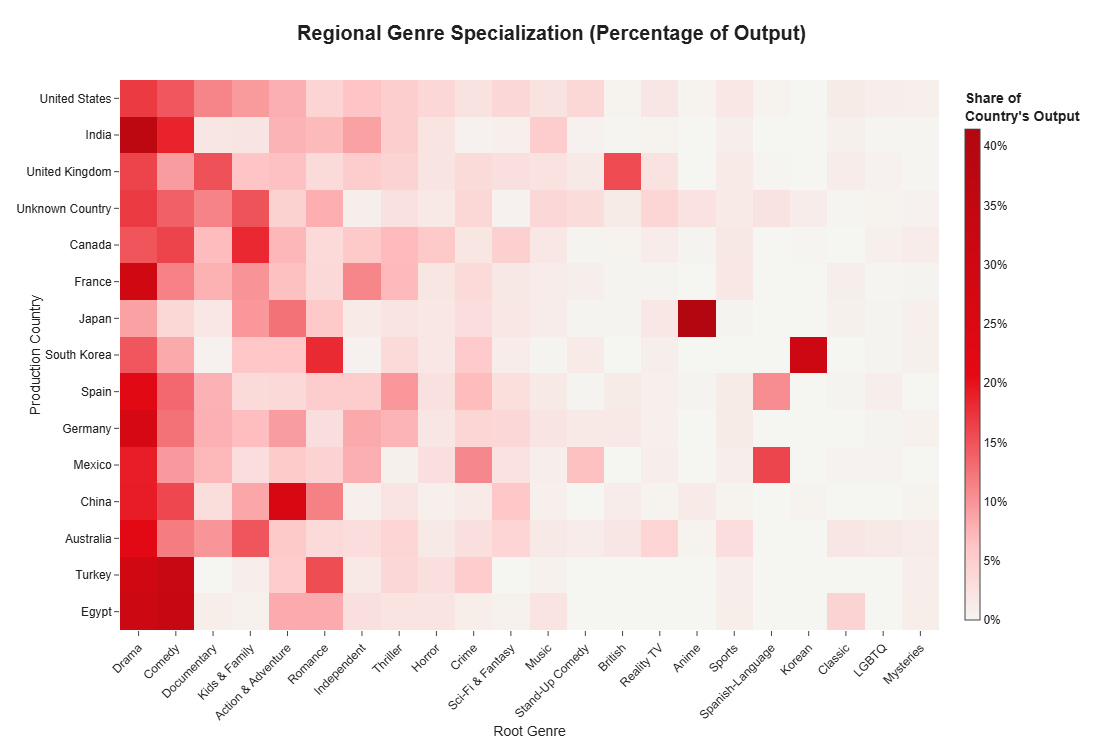

In [32]:
# ============================================================
# CHART 12 — REGIONAL GENRE SPECIALIZATION (HEATMAP)
# ============================================================

# 1. Prepare Data: Double-Explode to map every country to every genre
# First explode by country
df_geo = df.explode('country_list').dropna(subset=['country_list'])
df_geo = df_geo[df_geo['country_list'].str.strip() != '']

# Then explode by genre
df_matrix = df_geo.explode('genre_list').dropna(subset=['genre_list'])
df_matrix = df_matrix[df_matrix['genre_list'].str.strip() != '']

# 2. Re-apply the Root Genre logic to clean the tags
def get_root_genre(g):
    g = g.strip()
    if 'Stand-Up' in g: return 'Stand-Up Comedy'
    if 'Comed' in g: return 'Comedy'
    if 'Action' in g: return 'Action & Adventure'
    if 'Docum' in g or 'Docuseries' in g: return 'Documentary'
    if 'Sci-Fi' in g or 'Fantasy' in g: return 'Sci-Fi & Fantasy'
    if 'Crime' in g: return 'Crime'
    if 'Kid' in g or 'Children' in g: return 'Kids & Family'
    if 'Horror' in g: return 'Horror'
    if 'Thriller' in g: return 'Thriller'
    if 'Roman' in g: return 'Romance'
    if 'Drama' in g: return 'Drama'
    if 'Anime' in g: return 'Anime'
    if 'Music' in g: return 'Music'
    if 'Reality' in g: return 'Reality TV'
    return g.replace(' Movies', '').replace(' TV Shows', '').replace(' Series', '').replace('TV ', '').strip()

df_matrix['root_genre'] = df_matrix['genre_list'].apply(get_root_genre)

# ADD THIS LINE: Drop the redundant 'International' tag so true thematic genres can show
df_matrix = df_matrix[df_matrix['root_genre'] != 'International']

# 3. Filter for Top 15 Countries and Top 15 Root Genres to keep the grid readable
top_15_countries = df_matrix['country_list'].value_counts().head(15).index
top_22_genres = df_matrix['root_genre'].value_counts().head(22).index

df_matrix = df_matrix[
    (df_matrix['country_list'].isin(top_15_countries)) & 
    (df_matrix['root_genre'].isin(top_22_genres))
]

# 4. Create the Cross-Tabulation Matrix (Absolute Volume)
crosstab_vol = pd.crosstab(df_matrix['country_list'], df_matrix['root_genre'])

# Sort rows and columns by total volume so the biggest hubs are at the top/left
crosstab_vol = crosstab_vol.loc[top_15_countries, top_22_genres]

# 5. Convert to Row Percentages (Concentration)
# We divide every cell in a row by the total sum of that row
crosstab_pct = crosstab_vol.div(crosstab_vol.sum(axis=1), axis=0)

# Custom Continuous Scale: Light Gray (0%) -> Pink -> Brand Red -> Dark Red
heatmap_scale = [
    [0.0, '#F5F5F1'],                     # 0% Concentration: Light Gray
    [0.15, '#FFC5C6'],                    # Low Concentration: Light Pink
    [0.5, NETFLIX_COLORS['red']],         # Medium Concentration: Brand Red
    [1.0, NETFLIX_COLORS['dark_red']]     # High Concentration: Dark Red
]
# 6. Build the Plotly Figure (Heatmap)
fig12 = px.imshow(
    crosstab_pct,
    labels=dict(x="Root Genre", y="Production Country", color="Concentration"),
    x=crosstab_pct.columns,
    y=crosstab_pct.index,
    color_continuous_scale=heatmap_scale,
    aspect="auto"  # Ensures the rectangles stretch nicely across the screen
)

# 7. Apply Netflix-themed Layout Formatting
fig12.update_layout(
    height=750,
    title=dict(
        text='<b>Regional Genre Specialization (Percentage of Output)</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    xaxis=dict(
        tickangle=-45,                       # Tilt the genre labels so they don't overlap
        side='bottom',
        showgrid=False
    ),
    yaxis=dict(
        showgrid=False
    ),
    margin=dict(t=80, b=120, l=120, r=40),
    
    # Format the colorbar as percentages
    coloraxis_colorbar=dict(
        title="<b>Share of<br>Country's Output</b>",
        tickformat='.0%',
        thickness=15
    )
)

# 8. Customizing hover details to show both the percentage and the raw volume
# We inject the raw volume (crosstab_vol) into the customdata so we can display it in the tooltip
fig12.update_traces(
    customdata=crosstab_vol,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Genre: %{x}<br>"
        "Concentration: <b>%{z:.1%}</b><br>"
        "Titles: %{customdata:,}<extra></extra>"
    )
)

# 9. Display the Chart
fig12.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 13 — CATALOG STRUCTURAL HIERARCHY (SUNBURST)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Multi-tier Sunburst Chart (Plotly `px.sunburst`).
* **Engineered & Core Features:** Hierarchical path: `type` $\rightarrow$ `maturity_level` (1-5 Scale) $\rightarrow$ `root_genre` (Top 5 per branch).
* **Data Engineering Pivot:** 
  * *Demographic Roll-up:* We leverage the engineered 1-5 `maturity_level` to consolidate fragmented TV/MPAA ratings into clean tiers (Kids to Adults), dropping the <1% "Unrated (0)" noise. 
  * *Ring Pruning:* The outer genre ring is strictly limited to the Top 5 categories per demographic branch to prevent visual splintering.
* **Visual Rationale:** A Sunburst chart perfectly handles radial hierarchy. It allows stakeholders to trace the exact lineage of the catalog from Format, down to Audience, down to Genre.
* **Color Palette Mapping (Maturity Scale):** A 1-5 continuous color scale (Light Gray/Pink for Kids $\rightarrow$ Brand Red/Black for Adults). *Crucial visual behavior:* Plotly dynamically calculates the center rings (Movie/TV) as the weighted average of their children, making them glow deep red—a mathematical visualization of the platform's heavy mature skew.

#### ❓ BUSINESS QUESTION
How does target audience maturity distribute across formats, and which specific genres act as the foundational pillars for those demographics?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The chart visually proves that Netflix is fundamentally an **Adult/Mature** platform (evidenced by the deep red weighted average of the center rings). Tracing the hierarchy reveals strict genre-demographic boundaries: Adult TV is overwhelmingly driven by Drama and Crime, while Kids TV relies almost entirely on Animation and Family content.
* **Commercial Implication:** While Netflix markets itself as a family household necessity, its actual content acquisition pipeline is hyper-focused on mature audiences. It utilizes a massive, mature portfolio to drive engagement and retention, while maintaining a smaller, highly concentrated family portfolio for baseline household utility.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you color the chart by maturity level instead of just coloring it by total volume?"
* **Strategic Driver:** "In a Sunburst, the physical size of the slice already communicates volume. If I colored it by volume as well, I would be dual-encoding the exact same metric, wasting an opportunity for deeper analysis. By mapping color to the 1-5 maturity scale, the chart delivers two insights simultaneously: the size tells us *how much* content exists, and the heat gradient tells us *who* that content is actually built for."

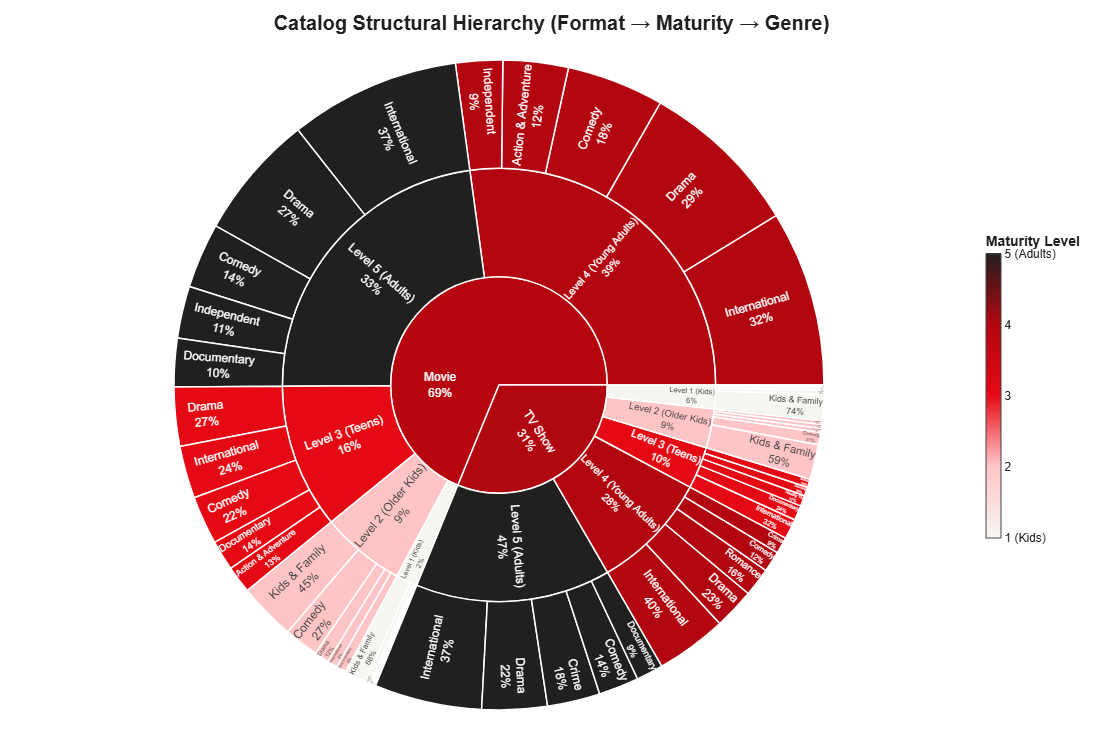

In [33]:
# ============================================================
# CHART 13 — CATALOG STRUCTURAL HIERARCHY (SUNBURST)
# ============================================================

# 1. Base Data: Filter out Unrated (0) and drop nulls
sunburst_df = df[df['maturity_level'] > 0].copy()
sunburst_df = sunburst_df.dropna(subset=['maturity_level', 'genre_list'])

# Map labels for display, but KEEP maturity_level for the color mapping
maturity_mapping = {
    1: 'Level 1 (Kids)',
    2: 'Level 2 (Older Kids)',
    3: 'Level 3 (Teens)',
    4: 'Level 4 (Young Adults)',
    5: 'Level 5 (Adults)'
}
sunburst_df['maturity_label'] = sunburst_df['maturity_level'].map(maturity_mapping)

# 2. Define root_genre function so this cell runs independently
def get_root_genre(g):
    g = g.strip()
    if 'Stand-Up' in g: return 'Stand-Up Comedy'
    if 'Comed' in g: return 'Comedy'
    if 'Action' in g: return 'Action & Adventure'
    if 'Docum' in g or 'Docuseries' in g: return 'Documentary'
    if 'Sci-Fi' in g or 'Fantasy' in g: return 'Sci-Fi & Fantasy'
    if 'Crime' in g: return 'Crime'
    if 'Kid' in g or 'Children' in g: return 'Kids & Family'
    if 'Horror' in g: return 'Horror'
    if 'Thriller' in g: return 'Thriller'
    if 'Roman' in g: return 'Romance'
    if 'Drama' in g: return 'Drama'
    if 'Anime' in g: return 'Anime'
    if 'Music' in g: return 'Music'
    if 'Reality' in g: return 'Reality TV'
    return g.replace(' Movies', '').replace(' TV Shows', '').replace(' Series', '').replace('TV ', '').strip()

# Explode genres and apply root_genre cleaner
sunburst_df = sunburst_df.explode('genre_list')
sunburst_df = sunburst_df[sunburst_df['genre_list'].str.strip() != '']
sunburst_df['root_genre'] = sunburst_df['genre_list'].apply(get_root_genre)

# NOTE: 'International' tag is retained here as it represents a valid global genre segment.

# 3. Prune the Outer Ring (Top 5 Genres per branch)
# Group by type, label, numeric level, and genre to get exact counts
branch_counts = sunburst_df.groupby(['type', 'maturity_label', 'maturity_level', 'root_genre']).size().reset_index(name='count')

# Sort by size and isolate the top 5 genres for each Type/Maturity combination
branch_counts = branch_counts.sort_values(['type', 'maturity_label', 'count'], ascending=[True, True, False])
top_branches = branch_counts.groupby(['type', 'maturity_label']).head(5)

# 4. Define the 5-Part Continuous Scale (Mapping to Levels 1-5)
# Level 1 (Light Gray) -> Level 5 (Netflix Black)
maturity_scale = [
    [0.0, '#F5F5F1'],                     # Level 1
    [0.25, '#FFC5C6'],                    # Level 2
    [0.5, '#E50914'],                     # Level 3 (Brand Red)
    [0.75, '#B20710'],                    # Level 4 (Dark Red)
    [1.0, '#221F1F']                      # Level 5 (Netflix Black)
]

# 5. Build the Plotly Figure (Sunburst)
fig13 = px.sunburst(
    top_branches,
    path=['type', 'maturity_label', 'root_genre'],
    values='count',
    color='maturity_level',               # Color is explicitly driven by the numeric 1-5 level
    color_continuous_scale=maturity_scale,
    range_color=[1, 5],                   # Lock the color scale strictly to our 1-5 range
    custom_data=['count', 'maturity_level']
)

# 6. Apply Netflix-themed Layout Formatting
fig13.update_layout(
    height=750,
    title=dict(
        text='<b>Catalog Structural Hierarchy (Format → Maturity → Genre)</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    margin=dict(t=60, b=40, l=40, r=40),
    
    # Restore the colorbar to act as a Maturity Legend for the user
    coloraxis_colorbar=dict(
        title="<b>Maturity Level</b>",
        tickvals=[1, 2, 3, 4, 5],
        ticktext=['1 (Kids)', '2', '3', '4', '5 (Adults)'],
        thickness=15,
        len=0.5
    )
)

# 7. Customizing text labels and hover details
fig13.update_traces(
    textinfo='label+percent parent',
    insidetextorientation='radial',
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Titles: %{customdata[0]:,}<br>"
        "Maturity Level: %{customdata[1]}<br>"
        "Share of Parent: %{percentParent:.1%}<extra></extra>"
    ),
    marker_line_width=1.5,
    marker_line_color='#FFFFFF'
)

# 8. Display the Chart
fig13.show()

# ============================================================
# 🎬 SECTION E: CREATIVE TALENT & NETWORK ANALYSIS
# ============================================================

### 📌 SECTION GOAL & STRATEGIC CONTEXT
Evaluate key creative collaborators, recurring talent networks, and directorial genre commitments. This section shifts the focus from *what* content is produced to *who* is producing it, identifying the key personnel that drive Netflix's global output.

### 🔑 KEY BUSINESS QUESTIONS ADDRESSED
* Who are the most frequently recurring directors and actors on the platform?
* Do top directors act as generalists across the catalog, or do they operate within hyper-specialized genre silos?
* Are the top talent networks globally recognizable, or are they driven by massive international hubs (like Bollywood or Anime)?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 14 — TOP 15 MOST FREQUENT DIRECTORS (LOLLIPOP)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Horizontal Lollipop Chart / Dot Plot (Plotly `go.Scatter`).
* **Engineered & Core Features:** `director_list` (exploded), Title Count.
* **Data Engineering Pivot (The Ghost Director):** The raw dataset contains a massive amount of nulls or placeholders for missing directors. Before exploding, we must actively filter out the engineered `'Uncredited Director'` tag to ensure our rankings reflect actual human talent, rather than a data entry void.
* **Visual Rationale:** Replaces the standard horizontal bar chart to prevent dashboard visual fatigue. The Lollipop chart maintains the strict hierarchical ranking required for a "Top 15" list, but its minimalist design (a thin line and a dot) gives the section a breathable, highly analytical feel.
* **Color Palette Mapping:**
  * Lines: Subtle Netflix Light Gray (`#E5E5E5`)
  * Markers (Dots): Brand Red (`#E50914`) to draw the stakeholder's eye directly to the volume endpoint.

#### ❓ BUSINESS QUESTION
Who are the primary recurring filmmakers driving the sheer volume of Netflix’s catalog?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** A common stakeholder assumption is that a global platform's top directors would be marquee Hollywood auteurs—names like Christopher Nolan, Steven Spielberg, or Quentin Tarantino. However, the data completely shatters this expectation. The highest-volume slots are overwhelmingly dominated by hyper-specialized regional powerhouses. 
* **Commercial Implication:** Netflix achieves raw volume not by paying astronomical fees for massive Hollywood directors, but by partnering with high-output regional specialists. For example, Rajiv Chilaka dominates the list through the mass production of Indian children's animation (*Chhota Bheem*), while Raúl Campos and Jan Suter generate massive volume through Latin American stand-up comedy specials.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you use a Lollipop chart here instead of just a standard bar chart?"
* **Strategic Driver:** "A dashboard needs visual pacing. I had already used dense, heavy stacked bars earlier in the geography section. Using another solid bar chart here would cause visual monotony. A Lollipop chart delivers the exact same ranked clarity, but drastically reduces visual clutter, allowing the audience to focus purely on the names and the data points."

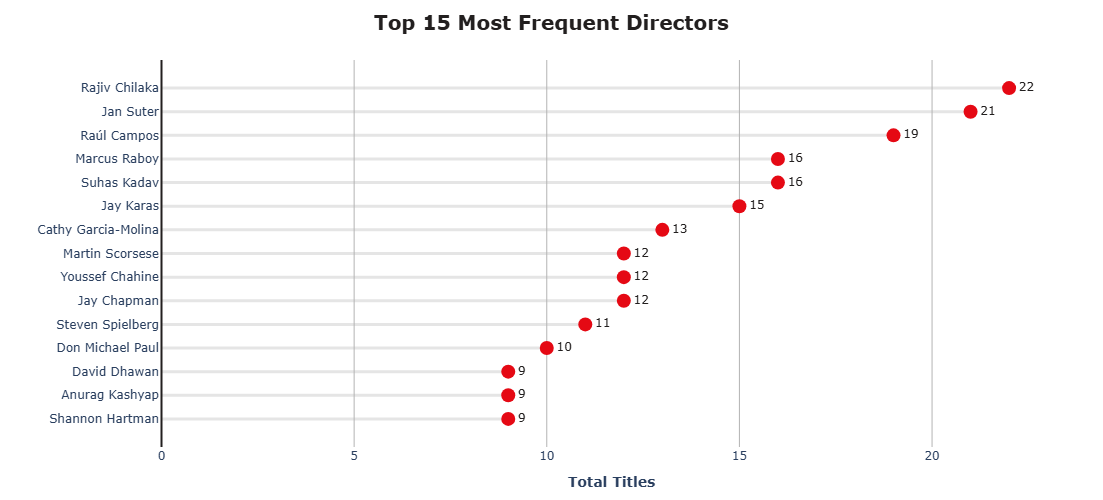

In [34]:
# ============================================================
# CHART 14 — TOP 15 MOST FREQUENT DIRECTORS (LOLLIPOP)
# ============================================================

# 1. Prepare Data: Explode the engineered 'director_list'
dir_df = df.explode('director_list').dropna(subset=['director_list'])
dir_df['director_list'] = dir_df['director_list'].str.strip()

# 2. Data Engineering Pivot (The Ghost Director): 
# Explicitly filter out empty strings and the 'Uncredited Director' tag
dir_df = dir_df[
    (dir_df['director_list'] != '') & 
    (dir_df['director_list'] != 'Uncredited Director')
]

# 3. Group by director and count the total titles
top_dirs = dir_df.groupby('director_list').size().reset_index(name='count')

# Grab the Top 15 by volume
top_dirs = top_dirs.sort_values('count', ascending=False).head(15)

# Sort ascending so the largest volume appears at the top of the horizontal Plotly chart
top_dirs = top_dirs.sort_values('count', ascending=True)

# 4. Build the Plotly Figure (Lollipop Chart)
fig14 = go.Figure()

# Add the 'Sticks' (Thin Lines behind the dots)
for i, row in top_dirs.iterrows():
    fig14.add_shape(
        type="line",
        x0=0,
        x1=row['count'],
        y0=row['director_list'],
        y1=row['director_list'],
        line=dict(color='#E5E5E5', width=3), # Netflix Light Gray
        layer='below'
    )

# Add the 'Pops' (Dots at the end of the lines)
fig14.add_trace(
    go.Scatter(
        x=top_dirs['count'],
        y=top_dirs['director_list'],
        mode='markers+text',
        marker=dict(color=NETFLIX_COLORS['red'], size=14),
        text=top_dirs['count'],                       # Adds the exact number next to the dot
        textposition='middle right',
        textfont=dict(size=12, color=NETFLIX_COLORS['black']),
        name='Titles',
        hovertemplate="<b>%{y}</b><br>Titles Directed: %{x}<extra></extra>"
    )
)

# 5. Apply Netflix-themed Layout Formatting
fig14.update_layout(
    height=500,
    title=dict(
        text='<b>Top 15 Most Frequent Directors</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    margin=dict(t=60, b=40, l=150, r=40), # Extra left margin for long director names
    xaxis=dict(
        title='<b>Total Titles</b>',
        showgrid=True,
        gridcolor=NETFLIX_COLORS['light_gray'],
        zeroline=True,
        zerolinecolor=NETFLIX_COLORS['black'],
        zerolinewidth=2
    ),
    yaxis=dict(
        title='',
        showgrid=False
    ),
    showlegend=False
)

# 6. Display the Chart
fig14.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 15 — TOP 15 MOST PROLIFIC CAST MEMBERS (LOLLIPOP)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Horizontal Lollipop Chart / Dot Plot (Plotly `go.Scatter`).
* **Engineered & Core Features:** `cast_list` (exploded), Title Count.
* **Data Engineering Pivot (The Ghost Cast):** Similar to the directorial analysis, we must actively filter out nulls, empty strings, and the engineered `'Uncredited Cast'` tag before aggregating the data to ensure we are ranking actual on-screen talent.
* **Visual Rationale:** Intentional design symmetry. By reusing the exact same Lollipop architecture established in Chart 14, we create a cohesive "Talent Profile" module. This avoids introducing a new chart type "on a whim" and reduces the stakeholder's cognitive load. 
* **Color Palette Mapping:**
  * Lines: Subtle Netflix Light Gray (`#E5E5E5`)
  * Markers (Dots): Brand Red (`#E50914`) to maintain continuity with the Directors chart.

#### ❓ BUSINESS QUESTION
Which actors act as the most frequent on-screen anchors across Netflix's original and licensed catalog?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The data decisively proves that the highest-volume actors are not American A-listers. The top spots are overwhelmingly dominated by Indian cinema icons (like Anupam Kher, Shah Rukh Khan, and Om Puri) alongside highly prolific Japanese anime voice actors (like Takahiro Sakurai).
* **Commercial Implication:** This exposes Netflix's massive strategic reliance on the Indian film industry (Bollywood/Tollywood) to drive catalog depth. Indian cinema produces feature films at a vastly higher volume than Hollywood, and Netflix licenses these massive back catalogs to maintain high retention in one of their most critical growth markets.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "You just used a Lollipop chart for the Directors. Why didn't you use a different visual here to mix things up?"
* **Strategic Driver:** "Changing a chart type merely for the sake of variety is a poor design practice that creates dashboard friction. Because Directors and Cast are twin metrics evaluating 'Talent,' they belong in the same visual family. Using structural symmetry allows the stakeholder to instantly read the second chart without having to parse a new geometric layout, keeping the focus entirely on the data insights."

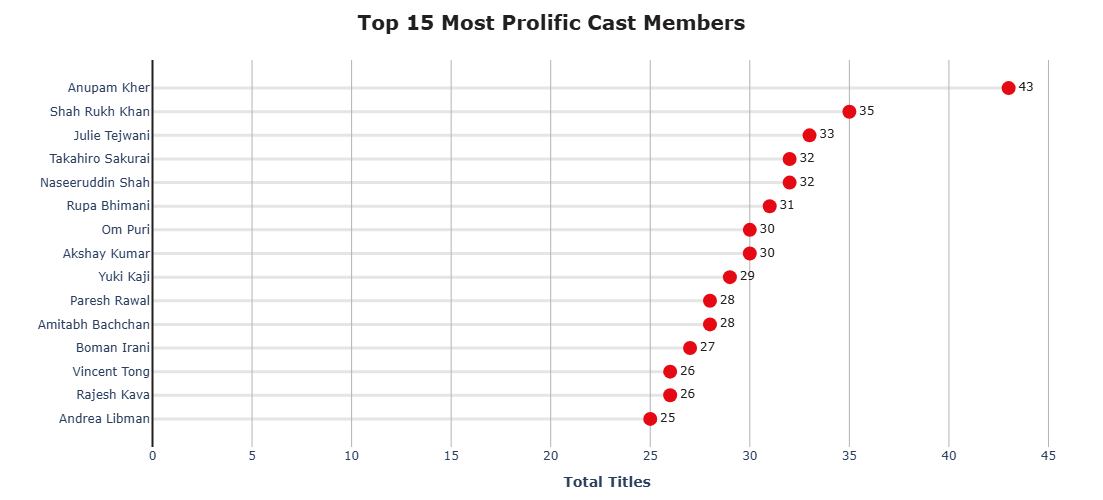

In [35]:
# ============================================================
# CHART 15 — TOP 15 MOST PROLIFIC CAST MEMBERS (LOLLIPOP)
# ============================================================

# 1. Prepare Data: Explode the engineered 'cast_list'
cast_df = df.explode('cast_list').dropna(subset=['cast_list'])
cast_df['cast_list'] = cast_df['cast_list'].str.strip()

# 2. Data Engineering Pivot (The Ghost Cast): 
# Explicitly filter out empty strings and the 'Uncredited Cast' tag
cast_df = cast_df[
    (cast_df['cast_list'] != '') & 
    (cast_df['cast_list'] != 'Uncredited Cast')
]

# 3. Group by cast member and count the total titles
top_cast = cast_df.groupby('cast_list').size().reset_index(name='count')

# Grab the Top 15 by volume
top_cast = top_cast.sort_values('count', ascending=False).head(15)

# Sort ascending so the largest volume appears at the top of the horizontal Plotly chart
top_cast = top_cast.sort_values('count', ascending=True)

# 4. Build the Plotly Figure (Lollipop Chart)
fig15 = go.Figure()

# Add the 'Sticks' (Thin Lines behind the dots)
for i, row in top_cast.iterrows():
    fig15.add_shape(
        type="line",
        x0=0,
        x1=row['count'],
        y0=row['cast_list'],
        y1=row['cast_list'],
        line=dict(color='#E5E5E5', width=3), # Netflix Light Gray
        layer='below'
    )

# Add the 'Pops' (Dots at the end of the lines)
fig15.add_trace(
    go.Scatter(
        x=top_cast['count'],
        y=top_cast['cast_list'],
        mode='markers+text',
        marker=dict(color=NETFLIX_COLORS['red'], size=14),
        text=top_cast['count'],                       # Adds the exact number next to the dot
        textposition='middle right',
        textfont=dict(size=12, color=NETFLIX_COLORS['black']),
        name='Titles',
        hovertemplate="<b>%{y}</b><br>Titles Appeared In: %{x}<extra></extra>"
    )
)

# 5. Apply Netflix-themed Layout Formatting
fig15.update_layout(
    height=500,
    title=dict(
        text='<b>Top 15 Most Prolific Cast Members</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    margin=dict(t=60, b=40, l=150, r=40), # Extra left margin for long cast names
    xaxis=dict(
        title='<b>Total Titles</b>',
        showgrid=True,
        gridcolor=NETFLIX_COLORS['light_gray'],
        zeroline=True,
        zerolinecolor=NETFLIX_COLORS['black'],
        zerolinewidth=2
    ),
    yaxis=dict(
        title='',
        showgrid=False
    ),
    showlegend=False
)

# 6. Display the Chart
fig15.show()

# ============================================================
# 🔬 SECTION F: MULTIDIMENSIONAL RELATIONSHIPS & ADVANCED SYNTHESIS
# ============================================================

### 📌 SECTION GOAL & STRATEGIC CONTEXT
Detect feature correlations, runtime patterns, and complex cross-variable flows. This final section acts as the synthesis layer, moving beyond single-variable distributions to uncover how format, duration, maturity, and release timing interact to drive Netflix's global content strategy.

### 🔑 KEY BUSINESS QUESTIONS ADDRESSED
* Are there optimal runtime or season-count windows for specific genres?
* How does content duration correlate with target audience maturity?
* Do complex, multi-variable interactions reveal hidden rules in Netflix's production and acquisition pipeline?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 16 — CATALOG VINTAGE & SHELF-LIFE (HISTOGRAM)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Distribution Histogram with Median Reference Line (Plotly `px.histogram`).
* **Engineered & Core Features:** `content_age` (Engineered: `2021 - release_year`), split by `type` (Movie vs. TV Show).
* **Data Engineering Pivot:** We calculate `content_age` using 2021 as the baseline (the final year of the dataset). We then categorize the X-axis into distinct strategic buckets: "New/Modern" (0-5 years), "Library" (6-15 years), and "Classic" (16+ years).
* **Visual Rationale:** A histogram is the optimal geometric shape to reveal skew and density. By plotting the age of the content on the X-axis and volume on the Y-axis, the resulting curve will visually prove the platform's extreme recency bias. Adding vertical lines for the Median age provides an immediate, hard executive takeaway.
* **Color Palette Mapping:**
  * Movies: Brand Red (`#E50914`)
  * TV Shows: Netflix Black/Dark Gray (`#221F1F`)
  * Reference Lines: Subtle contrasting color or dashed black line.

#### ❓ BUSINESS QUESTION
Is Netflix's value proposition driven by a deep archival library, or is it fundamentally a recency-biased platform? What is the actual median shelf-life of an available title?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The histogram will reveal a massive, heavily skewed right-tail distribution (meaning the bulk of the data sits close to 0-5 years of age). The median age of the catalog is shockingly young proving that almost the entire library was produced within a very recent window. Furthermore, TV Shows have an even younger median age than Movies.
* **Commercial Implication:** Netflix operates almost entirely on "freshness" rather than nostalgia. Unlike Disney+ (which relies on a century-old vault) or HBO, Netflix trains its algorithm and user base to constantly consume the "new." Content older than 10 years forms an almost negligible part of their retention strategy.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you engineer `content_age` instead of just plotting the raw `release_year` on the X-axis?"
* **Strategic Driver:** "Plotting '1995' vs. '2015' forces the stakeholder to do mental math to figure out how old that content is today. By engineering a `content_age` metric (0, 5, 10 years old), I translated a static date into a dynamic business metric ('Shelf-Life'). This instantly answers the question of whether Netflix relies on modern content or deep-library syndication."

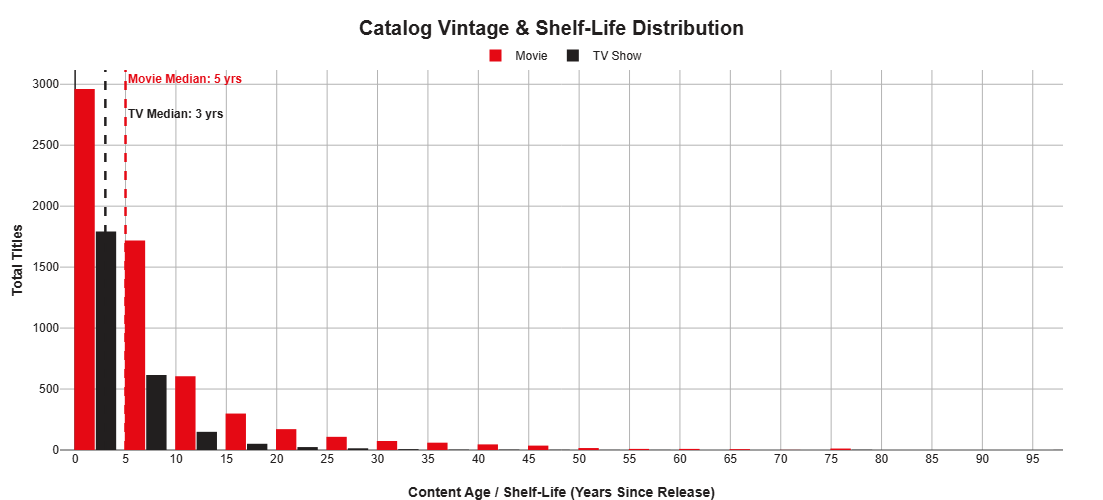

In [36]:
# ============================================================
# CHART 16 — CATALOG VINTAGE & SHELF-LIFE (HISTOGRAM)
# ============================================================

# 1. Prepare Data: Engineer the 'content_age' feature
# Baseline 2021 (max release year in dataset)
df['content_age'] = 2021 - df['release_year']
vintage_df = df[df['content_age'] >= 0].copy()

# 2. Calculate Medians for Reference Lines
median_age_movie = vintage_df[vintage_df['type'] == 'Movie']['content_age'].median()
median_age_tv = vintage_df[vintage_df['type'] == 'TV Show']['content_age'].median()

# 3. Build the Plotly Figure (Histogram)
fig16 = px.histogram(
    vintage_df,
    x='content_age',
    color='type',
    color_discrete_map={
        'Movie': NETFLIX_COLORS['red'], 
        'TV Show': NETFLIX_COLORS['black']
    },
    barmode='group',
    nbins=45
)

# 4. Staggered Reference Lines (Prevents Nameplate Collision)
# Movie Median (Positioned Top-Right)
fig16.add_vline(
    x=median_age_movie, 
    line_width=2.5, 
    line_dash="dash", 
    line_color=NETFLIX_COLORS['red'],
    annotation_text=f"Movie Median: {int(median_age_movie)} yrs", 
    annotation_position="top right",
    annotation_font=dict(color=NETFLIX_COLORS['red'], size=12, weight='bold'),
    annotation_yshift=0
)

# TV Show Median (Positioned Top-Right with negative Y-offset)
fig16.add_vline(
    x=median_age_tv, 
    line_width=2.5, 
    line_dash="dash", 
    line_color=NETFLIX_COLORS['black'],
    annotation_text=f"TV Median: {int(median_age_tv)} yrs", 
    annotation_position="top right",
    annotation_font=dict(color=NETFLIX_COLORS['black'], size=12, weight='bold'),
    annotation_yshift=-35,
    annotation_xshift=20  # <--- Adds left padding (pushes the text further to the right)
)

# 5. Apply Refined Layout & Axis Spacing
max_age = vintage_df['content_age'].max()

fig16.update_layout(
    height=500,
    title=dict(
        text='<b>Catalog Vintage & Shelf-Life Distribution</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    margin=dict(t=70, b=50, l=60, r=40),
    
    # Clean bar separation
    bargap=0.15,
    bargroupgap=0.05,
    
    xaxis=dict(
        title='<b>Content Age / Shelf-Life (Years Since Release)</b>',
        range=[-1.5, max_age + 2],         # Left padding prevents overlap with Y-axis
        dtick=5,                            # Neat 5-year step markers
        showgrid=True,
        gridcolor=NETFLIX_COLORS['light_gray'],
        zeroline=True,
        zerolinecolor=NETFLIX_COLORS['black'],
        zerolinewidth=1.5
    ),
    yaxis=dict(
        title='<b>Total Titles</b>',
        showgrid=True,
        gridcolor=NETFLIX_COLORS['light_gray']
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.0,
        xanchor='center',
        x=0.5,
        title=None,
        font=dict(size=12, color=NETFLIX_COLORS['black'])
    )
)

# 6. Clean Tooltip
fig16.update_traces(
    hovertemplate="<b>%{data.name}</b><br>Content Age: %{x} Years<br>Titles: %{y}<extra></extra>"
)

# 7. Display the Chart
fig16.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 17 — DURATION BUCKET VS. MATURITY LEVEL HEATMAP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Cross-Tabulation Matrix Heatmap with In-Cell Annotations (Plotly `px.imshow`).
* **Engineered & Core Features:** `duration_bucket` (Y-axis: discrete runtime and season tiers), `maturity_level` (X-axis: Levels 1–5).
* **Data Engineering Pivot:** Excludes unrated (`maturity_level == 0`) and unassigned duration buckets (`!= 0`). Y-axis sorting is explicitly managed so Movie categories and TV categories group logically.
* **Visual Rationale:** Solves the "Hidden Volume" problem of box plots. By binning durations into categorical buckets and running a crosstab against maturity, the heatmap instantly highlights the exact coordinates where Netflix concentrates its production volume.
* **Color Palette Mapping:**
  * Base: White / Light Gray (`#F5F5F1`) for empty/low-volume cells.
  * Peak Concentration: Brand Red / Dark Burgundy (`#E50914` / `#550308`) for the highest volume cells.
  * Text: Auto-contrasting text (`text_auto=True`) to ensure readability.

#### ❓ BUSINESS QUESTION
Where does Netflix allocate its highest volume of content, and how does the sweet spot for narrative duration change based on target audience maturity?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The absolute center of gravity for the entire Netflix catalog is the **90–120 minute duration window at Maturity Level 4 (Adult)**, representing the highest concentration of titles on the platform.
* **Commercial Implication:** Confirms that despite experimental formats, the platform's core acquisition and production strategy still revolves around the standard 1.5 to 2-hour mature feature film, paired with high volumes of single-season TV shows across all demographics.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why utilize a categorical heatmap to analyze duration and maturity instead of a standard box plot showing statistical distributions?"
* **Strategic Driver:** "Box plots are excellent for finding medians and outliers, but they suffer from 'hidden volume'—they cannot visualize the absolute scale of the data. A box plot might indicate that Level 4 (Adult) content averages 95 minutes, but it masks whether that represents 50 titles or 2,000. By grouping durations into discrete buckets and mapping them onto a heatmap, we immediately expose the actual mass of the catalog. It allows stakeholders to instantly identify exactly where Netflix concentrates its production budget and acquisition volume, rather than just viewing statistical variance."

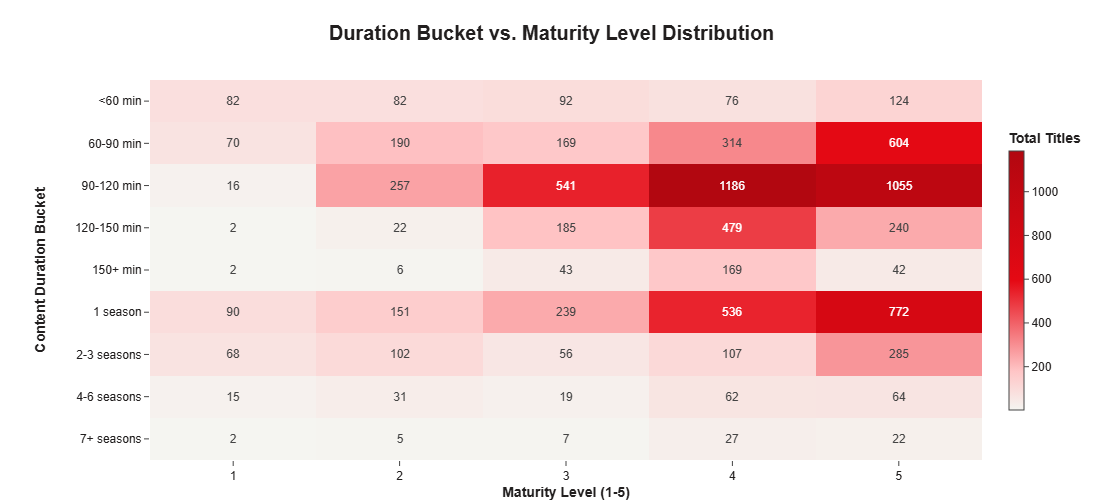

In [37]:
# ============================================================
# CHART 17 — DURATION BUCKET VS. MATURITY LEVEL HEATMAP
# ============================================================

# 1. Custom Continuous Scale (Exactly as requested)
heatmap_scale = [
    [0.0, '#F5F5F1'],                     # 0% Concentration: Light Gray
    [0.15, '#FFC5C6'],                    # Low Concentration: Light Pink
    [0.5, NETFLIX_COLORS['red']],         # Medium Concentration: Brand Red
    [1.0, NETFLIX_COLORS['dark_red']]     # High Concentration: Dark Red
]

# 2. Create the Cross-Tabulation Matrix
pivot_dm = pd.crosstab(
    df.loc[
        (df['maturity_level'] != 0) & (df['duration_bucket'] != 0),
        'duration_bucket'
    ],
    df.loc[
        (df['maturity_level'] != 0) & (df['duration_bucket'] != 0),
        'maturity_level'
    ]
)

# 3. BULLETPROOF Y-AXIS SORTING ENGINE
# This function assigns a numerical weight to each string so it sorts chronologically 
# (Movies first, then TV Shows) without relying on exact spelling.
def sort_buckets(bucket_name):
    name = str(bucket_name).lower()
    # Movie Buckets (Weights 1-4)
    if 'min' in name:
        if '<' in name: return 1
        if '60' in name: return 2
        if '90' in name: return 3
        if '>' in name: return 4
        return 5
    # TV Show Buckets (Weights 11-14)
    if 'season' in name:
        if '1' in name: return 11
        if '2' in name: return 12
        if '3' in name: return 13
        if '4' in name or '+' in name: return 14
        return 15
    return 99

# Apply the sorting engine to the Y-axis
sorted_index = sorted(pivot_dm.index, key=sort_buckets)
pivot_dm = pivot_dm.reindex(sorted_index)

# 4. Build the Plotly Figure (Heatmap)
fig17 = px.imshow(
    pivot_dm,
    text_auto=True,
    aspect="auto",
    color_continuous_scale=heatmap_scale
)

# 5. Apply Netflix-themed Layout Formatting
fig17.update_layout(
    height=500,
    title=dict(
        text='<b>Duration Bucket vs. Maturity Level Distribution</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    margin=dict(t=80, b=40, l=150, r=40),
    
    # Format the color scale legend
    coloraxis_colorbar=dict(
        title="<b>Total Titles</b>",
        thicknessmode="pixels", thickness=15,
        lenmode="pixels", len=300,
        yanchor="middle", y=0.5,
        ticks="outside"
    )
)

# 6. Explicitly set and override axis titles
fig17.update_xaxes(
    title_text="<b>Maturity Level (1-5)</b>",
    type='category',
    side='bottom',
    showgrid=False
)

fig17.update_yaxes(
    title_text="<b>Content Duration Bucket</b>", 
    title_standoff=25,
    type='category',
    showgrid=False
)

# 7. Display the Chart
fig17.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 18 — TEMPORAL SHIFT IN GENRE STRATEGY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Normalized Multi-Line Time Series (Plotly `go.Scatter`).
* **Engineered & Core Features:** `year_added` (X-axis, filtered 2015–2021), `genre_root` (Lines, Top 6 highest-volume only), Normalized % Share (Y-axis).
* **Data Engineering Pivot:** 
  * Explode the `genre_list` and apply the `genre_root` mapping to unify fragmented TV/Movie tags into master categories.
  * *Crucial Step:* Convert raw volume counts into **Normalized Percentage Share** per year. Because Netflix's total volume exploded after 2016, a raw count chart just goes "up and to the right" for everything. Normalizing to 100% reveals true strategic reprioritization (budget share).
* **Visual Rationale:** A line chart is the optimal geometry for time-series trajectory. By restricting it to the Top 6 roots, we avoid the "spaghetti chart" trap and maintain a clean, scannable visual.
* **Color Palette Mapping:**
  * Rising/Surging Categories (e.g., International, Documentary): Brand Red (`#E50914`) / Dark Red.
  * Declining/Legacy Categories (e.g., Comedy, Drama): Subtle Grays/Blacks (`#221F1F`, `#8C8C8C`) to establish baseline context without competing for attention.

#### ❓ BUSINESS QUESTION
How has Netflix reallocated its content acquisition and production budget across macro-genres since its global expansion in 2016?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Catalog Finding:** The data reveals a distinct "scissors effect" post-2016. The relative share of traditional American staples (Standard Comedies and Dramas) steadily declines as a percentage of the total pipeline. Simultaneously, International features/series and Documentaries experience a massive, sustained upward trajectory.
* **Commercial Implication:** This mathematically visualizes Netflix's January 2016 global expansion. To retain audiences in 130+ new countries, Netflix heavily shifted budget away from expensive Hollywood licensing and poured it into regional/international production and highly bingeable, universally translatable formats like Docuseries.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you plot Percentage Share instead of Raw Volume, and why only 6 lines?"
* **Strategic Driver:** "Plotting raw volume just proves that Netflix grew overall—it hides the underlying strategy. By plotting normalized percentage share, I isolated the exact shifts in budget allocation. I restricted the chart to the Top 6 `genre_roots` because adding 15 lines creates an unreadable 'spaghetti chart.' The Top 6 capture the macro-strategic pivot without sacrificing visual clarity."

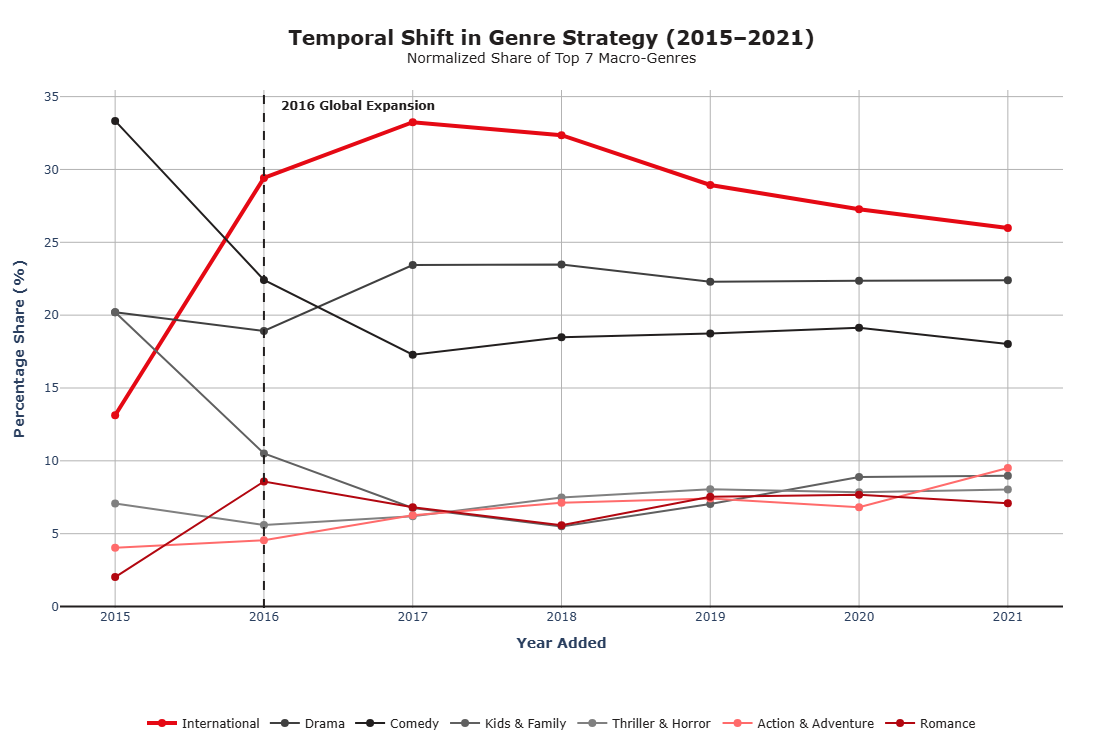

In [38]:
# ============================================================
# CHART 18 — TEMPORAL SHIFT IN GENRE STRATEGY (TOP 7)
# ============================================================

# 1. Filter for the relevant strategic window (2015-2021)
time_df = df[(df['year_added'] >= 2015) & (df['year_added'] <= 2021)].copy()

# 2. Explode the genre_list
genre_exploded = time_df.explode('genre_list').dropna(subset=['genre_list'])
genre_exploded['genre_list'] = genre_exploded['genre_list'].str.strip()

# 3. Unified genre_root mapping (Explicitly preserving 'International')
def map_genre_root(g):
    g = str(g).lower()
    if 'international' in g: return 'International'
    if 'comed' in g: return 'Comedy'
    if 'drama' in g: return 'Drama'
    if 'documentar' in g: return 'Documentary'
    if 'action' in g or 'adventure' in g: return 'Action & Adventure'
    if 'kid' in g or 'children' in g or 'family' in g: return 'Kids & Family'
    if 'thrill' in g or 'horror' in g: return 'Thriller & Horror'
    if 'romanc' in g or 'romantic' in g: return 'Romance'
    return 'Other'

genre_exploded['genre_root'] = genre_exploded['genre_list'].apply(map_genre_root)

# Drop 'Other' so we only measure the major defined roots
genre_exploded = genre_exploded[genre_exploded['genre_root'] != 'Other']

# 4. Rank to get the Top 7 Genres overall
top_7_genres = genre_exploded['genre_root'].value_counts().head(7).index.tolist()

# Filter dataset to only include these Top 7 heavy hitters
genre_top7 = genre_exploded[genre_exploded['genre_root'].isin(top_7_genres)]

# 5. Group by Year and calculate Normalized Share (%)
yearly_counts = genre_top7.groupby(['year_added', 'genre_root']).size().reset_index(name='count')

# Calculate the total count for these 7 genres per year to find the % share
yearly_totals = yearly_counts.groupby('year_added')['count'].transform('sum')
yearly_counts['share_pct'] = (yearly_counts['count'] / yearly_totals) * 100

# 6. Build the Plotly Multi-Line Chart
fig18 = go.Figure()

# Updated palette: Swapped Documentary for Romance
genre_colors = {
    'International': NETFLIX_COLORS['red'],       # Bold Brand Red
    'Romance': NETFLIX_COLORS['dark_red'],        # <--- Fixed: Dark Red
    'Action & Adventure': '#FF6B6B',              # Lighter Red/Pink
    'Comedy': '#221F1F',                          # Netflix Black
    'Drama': '#404040',                           # Very Dark Gray
    'Kids & Family': '#606060',                   # Medium-Dark Gray
    'Thriller & Horror': '#808080'                # Solid Standard Gray
}

for genre in top_7_genres:
    genre_data = yearly_counts[yearly_counts['genre_root'] == genre].sort_values('year_added')
    
    line_color = genre_colors.get(genre, '#606060')
    
    # ONLY International gets the bold weight (4). All others are uniform (2).
    line_width = 4 if genre == 'International' else 2
 
    fig18.add_trace(
        go.Scatter(
            x=genre_data['year_added'],
            y=genre_data['share_pct'],
            mode='lines+markers',
            name=genre,
            line=dict(color=line_color, width=line_width),
            marker=dict(size=8, color=line_color),
            hovertemplate=f"<b>{genre}</b><br>Year: %{{x}}<br>Share: %{{y:.1f}}%<extra></extra>"
        )
    )

# 7. Apply Netflix-themed Layout Formatting
fig18.update_layout(
    height=750,
    title=dict(
        text='<b>Temporal Shift in Genre Strategy (2015–2021)</b><br><sup>Normalized Share of Top 7 Macro-Genres</sup>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    margin=dict(t=90, b=50, l=60, r=40),
    xaxis=dict(
        title='<b>Year Added</b>',
        tickmode='linear',
        dtick=1,                            # Show every single year (2015, 2016, etc.)
        showgrid=True,
        gridcolor=NETFLIX_COLORS['light_gray'],
        zeroline=False
    ),
    yaxis=dict(
        title='<b>Percentage Share (%)</b>',
        showgrid=True,
        gridcolor=NETFLIX_COLORS['light_gray'],
        zeroline=True,
        zerolinecolor=NETFLIX_COLORS['black']
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.25,
        xanchor='center',
        x=0.5,
        font=dict(size=12, color=NETFLIX_COLORS['black'])
    ),
    hovermode='x unified' # Shows a single vertical line with all genre values for that year
)

# 8. Add a vertical annotation line for the 2016 Global Expansion
fig18.add_vline(
    x=2016, 
    line_width=2, 
    line_dash="dash", 
    line_color=NETFLIX_COLORS['black']
)
fig18.add_annotation(
    x=2016.1, 
    y=yearly_counts['share_pct'].max(),
    text="<b>2016 Global Expansion</b>",
    showarrow=False,
    xanchor="left",
    yshift=15,
    font=dict(color=NETFLIX_COLORS['black'], size=12)
)

# 9. Display the Chart
fig18.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 19 — MACRO-GENRE LANDSCAPE: ERA, DURATION & MATURITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Dual-Facet Interactive Bubble Scatter Plot (Plotly `px.scatter`).
* **Engineered & Core Features (The 5 Dimensions):** 
  * **Entity (The Bubble):** `genre_root` (Top ~10 macro-categories permanently labeled).
  * **X-Axis:** Average `release_year` (Legacy catalog vs. Modern push).
  * **Y-Axis:** Average `duration_value` (Independent axes: Minutes for Movies, Seasons for TV).
  * **Bubble Size:** Total Title Volume (Strategic weight/investment in the catalog).
  * **Color Scale:** Average `maturity_level` (Continuous gradient).
* **Data Engineering Pivot:** 
  * Replaces raw `genre_list` with the engineered `genre_root` to consolidate hundreds of fragmented micro-slices into ~10 definitive strategic pillars per format.
  * Aggregates metrics to the mean (`mean()` for year, duration, and maturity) and counts volume (`size()`) to build a clean summary table prior to plotting.
* **Visual Rationale:** This "Gapminder-style" scatter plot visualizes 5 variables simultaneously without overwhelming the viewer. Because the bubble count is reduced to only the macro-genres, text labels can remain permanently visible on the canvas—no hovering required to identify the largest clusters.
* **Color Palette Mapping:**
  * Custom Continuous Gradient: Netflix Black (Low average maturity, e.g., Kids/Family) transitioning to Netflix Red (High average maturity, e.g., Thrillers/Documentaries).

#### ❓ BUSINESS QUESTION
How do macro-genres differentiate themselves across release eras, audience demographics, and runtime commitments, and where does Netflix concentrate its heaviest acquisition volume?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Strategic Positioning (Movies):** Instantly reveals the coordinates of Netflix's film strategy. For example, it visually proves if Documentaries skew highly modern (far right X) and mature (Dark Red) but require shorter attention spans (lower Y), while Drama/International/Comedy dominates the volume (massive bubbles).
* **Strategic Positioning (TV Shows):** Differentiates viewer commitment requirements. It exposes whether Kids' Animation (black color) sustains longer/shorter/similar multi-season runs (on Y axis) compared to modern adult thrillers (Dark Red).

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "Why did you group by `genre_root` instead of your original approach utilizing raw `genre_list` and distinct `maturity_level` categories?"
* **Strategic Driver:** "The original grouping created severe fragmentation—hundreds of tiny, overlapping bubbles pulled toward the center by the law of averages, making the chart an unreadable blob. By aggregating up to `genre_root`, I eliminated the noise. This allowed me to map average maturity directly to a color gradient and keep the genre text labels permanently visible, instantly showing executives exactly where the catalog's volume, demographic focus, and duration intersect."

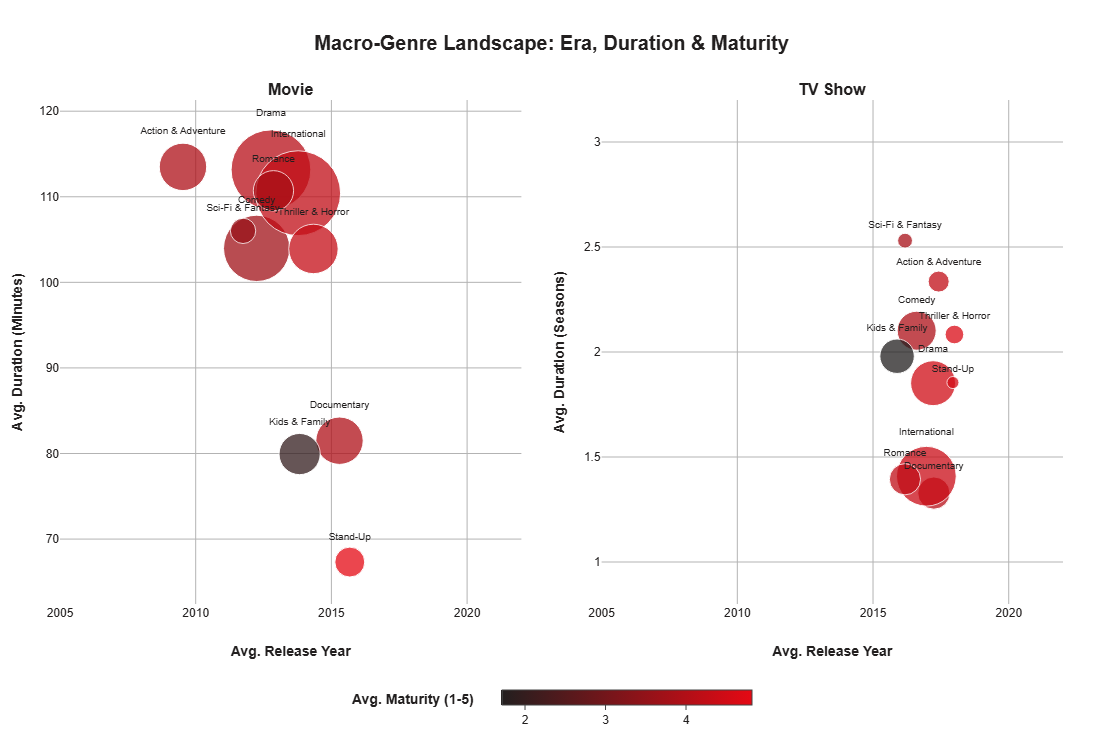

In [39]:
# ============================================================
# CHART 19 — MACRO-GENRE LANDSCAPE (REVISED)
# ============================================================

# 1. Filter out unrated content
df_b = df[df['maturity_level'] > 0].copy()

# 2. Explode the genre_list
df_b = df_b.explode('genre_list').dropna(subset=['genre_list'])
df_b['genre_list'] = df_b['genre_list'].astype(str).str.strip()

# 3. FIXED LOGIC: Reordered to prevent 'Comedy' and 'Drama' from swallowing specific genres
def map_genre_root(g):
    g = g.lower()
    if 'international' in g: return 'International'
    if 'stand-up' in g: return 'Stand-Up'              # Must come BEFORE Comedy
    if 'sci-fi' in g or 'fantasy' in g: return 'Sci-Fi & Fantasy'
    if 'docu' in g: return 'Documentary'               # Catches "Documentaries" AND "Docuseries"
    if 'comed' in g: return 'Comedy'
    if 'action' in g or 'adventure' in g: return 'Action & Adventure'
    if 'kid' in g or 'children' in g or 'family' in g: return 'Kids & Family'
    if 'thrill' in g or 'horror' in g: return 'Thriller & Horror'
    if 'romanc' in g or 'romantic' in g: return 'Romance'
    if 'drama' in g: return 'Drama'
    return 'Other'

df_b['genre_root'] = df_b['genre_list'].apply(map_genre_root)
df_b = df_b[df_b['genre_root'] != 'Other']

# 4. Aggregate the 5 Dimensions
bubble_summary = df_b.groupby(['type', 'genre_root']).agg(
    Avg_Release_Year=('release_year', 'mean'),
    Avg_Duration=('duration_value', 'mean'),
    Avg_Maturity=('maturity_level', 'mean'),
    Total_Volume=('genre_root', 'count')
).reset_index()

# 5. Build the Interactive Bubble Chart
fig19 = px.scatter(
    bubble_summary,
    x='Avg_Release_Year',
    y='Avg_Duration',
    size='Total_Volume',
    color='Avg_Maturity',
    facet_col='type',
    facet_col_spacing=0.08,  # <--- ADD THIS LINE (Creates a gap between subplots),
    text='genre_root',
    size_max=60,
    hover_name='genre_root',
    # FIXED: Netflix Black to Red scale
    color_continuous_scale=[
        [0.0, NETFLIX_COLORS['black']],
        [1.0, NETFLIX_COLORS['red']]
    ]
)

# 6. Apply Netflix-themed Layout Formatting
fig19.update_layout(
    height=750,  # Slightly taller to accommodate the bottom legend
    title=dict(
        text='<b>Macro-Genre Landscape: Era, Duration & Maturity</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    margin=dict(t=100, b=120, l=60, r=40),  # Increased bottom margin for legend
    
    # FIXED: Moved Color Bar to the bottom for horizontal breathing room
    coloraxis_colorbar=dict(
        title="<b>Avg. Maturity (1-5)</b>",
        orientation="h",
        thicknessmode="pixels", thickness=15,
        lenmode="fraction", len=0.4,
        yanchor="top", y=-0.15,
        xanchor="center", x=0.5,
        ticks="outside"
    )
)

# 7. Customize Facets and Independent Axes
# Clean up subplot titles
fig19.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.split('=')[1]}</b>", font=dict(size=16)))

# Format text labels
fig19.update_traces(textposition='top center', textfont=dict(color=NETFLIX_COLORS['black'], size=10),marker=dict(opacity=0.75))  # <--- ADD THIS ARGUMENT)

# FIXED: Independent Y-Axes with forced tick labels and aligned gridlines (nticks)
fig19.update_yaxes(matches=None, showticklabels=True, showgrid=True, gridcolor=NETFLIX_COLORS['light_gray'], nticks=7)
fig19.update_yaxes(title_text='<b>Avg. Duration (Minutes)</b>', row=1, col=1)
fig19.update_yaxes(title_text='<b>Avg. Duration (Seasons)</b>',range=[0.8, 3.2], row=1, col=2)

# FIXED: Stretched X-Axis Range (2005 - 2022)
fig19.update_xaxes(
    range=[2005, 2022], 
    showgrid=True, 
    gridcolor=NETFLIX_COLORS['light_gray'], 
    title_text='<b>Avg. Release Year</b>',
    nticks=7
)

# 8. Display the Chart
fig19.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 CHART 20 — END-TO-END CATALOG FLOW (INTERACTIVE CAPSTONE)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** Interactive Parallel Categories Diagram (Plotly `px.parallel_categories`).
* **Engineered & Core Features (The 3 Pillars):** 
  * `country` (Node 1: Top 5 known origins, strictly excluding "Unknown").
  * `format_genre` (Node 2: A merged engineered feature pairing Content Type and Macro-Genre, e.g., "Movie - Drama").
  * `maturity_level` (Node 3: Target audience tier, strictly ordered 5 down to 1).
* **Data Engineering Pivot:** 
  * Aggressively filtered to remove nulls, unrated content, and ghost tags (like variations of "Unknown Country"). 
  * Reduced from 4 variables down to a 3-pillar structure by merging Format and Genre, significantly reducing visual cross-threading while maintaining the full analytical narrative.
  * Node ordering is hardcoded (Countries by volume, Format/Genres grouped symmetrically, and Maturity ordered chronologically) to prevent the rendering engine from randomly shuffling the data flows.
* **Visual Rationale:** Acts as the exploratory capstone of the dashboard. Instead of static isolation, this visual allows the user to interactively trace the volume of how content originates in a specific region and funnels into a final demographic.
* **Color Palette Mapping:**
  * Ribbons are anchored and colored by the Origin Country (Pillar 1) using a distinct 5-color Netflix palette. This allows the user to easily track a specific regional pipeline (e.g., the red US pipeline or black India pipeline) completely across the screen without colors bleeding into a muddy gradient.

#### ❓ BUSINESS QUESTION
What is the macro end-to-end pipeline of Netflix's content, and how do regional origins dictate the format, thematic genre, and target demographic of the final product?

#### 💡 KEY INSIGHTS & TAKEAWAYS
* **Regional Specialization:** Interacting with the chart visually proves distinct production strategies. Highlighting India reveals a massive, concentrated funnel directly into Movie Dramas/Action, whereas highlighting the United Kingdom reveals a much wider, fragmented split into TV Shows and Comedies.
* **Demographic Pooling:** By tracing the country-colored ribbons to the final pillar, it becomes instantly clear which global hubs are responsible for supplying Netflix's heaviest TV-MA (Level 5) adult content versus family-friendly tiers.

#### 🎙️ EXECUTIVE DEEP DIVE
* **Business Inquiry:** "This chart contains a lot of intersecting lines. Why did you choose this visualization, and why did you merge Format and Genre into a single column?"
* **Strategic Driver:** "Parallel Category charts can easily fall into the 'spaghetti trap.' To prevent cognitive overload, I dropped the layout from 4 pillars to 3 by merging Format and Genre. This eliminated the massive crisscrossing that happens when trying to map Movies into 5 different genres. I then colored the ribbons by the Origin Country so the eye has a solid anchor to follow from left to right. Because this is deployed in an interactive Streamlit environment, the initial density is intentional—it acts as an exploratory tool where the user can click on any specific node, like 'South Korea', to isolate and highlight just that pipeline."

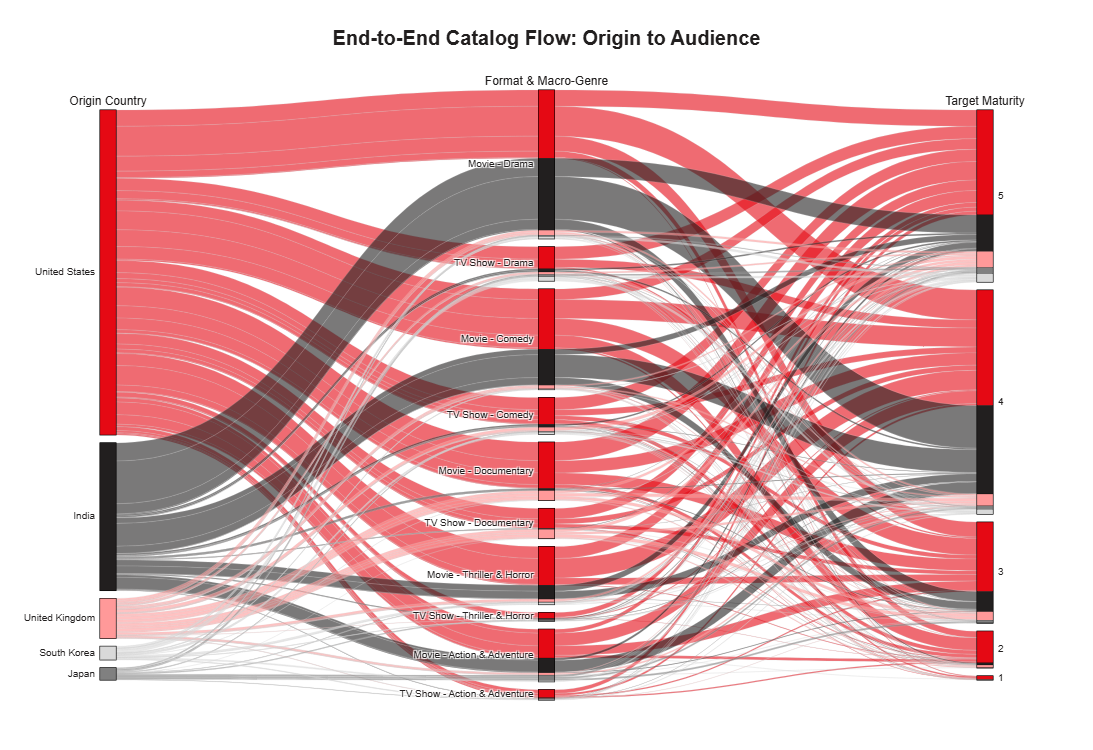

In [43]:
# ============================================================
# CHART 20 — END-TO-END CATALOG FLOW (ORDERED 3-PILLAR)
# ============================================================

# 1. Aggressive Base Filters
df_cap = df[df['maturity_level'] > 0].copy()

# FIXED: Wildcard check permanently purges "Unknown", "Unknown Country", etc.
df_cap = df_cap.dropna(subset=['country'])
df_cap = df_cap[~df_cap['country'].astype(str).str.lower().str.contains('unknown')]
df_cap = df_cap[df_cap['country'].astype(str).str.strip() != '']

# 2. Get Top 5 Countries by volume
top_5_countries = df_cap['country'].value_counts().head(5).index.tolist()
df_cap = df_cap[df_cap['country'].isin(top_5_countries)]

# Numerical index for Country-based coloring
country_mapping = {country: i for i, country in enumerate(top_5_countries)}
df_cap['country_color_index'] = df_cap['country'].map(country_mapping)

# 3. Explode genre_list
df_cap = df_cap.explode('genre_list').dropna(subset=['genre_list'])
df_cap['genre_list'] = df_cap['genre_list'].astype(str).str.strip()

# 4. CAPSTONE GENRE MAPPING (Excluding 'International')
def map_genre_root_capstone(g):
    g = g.lower()
    if 'stand-up' in g: return 'Stand-Up'
    if 'sci-fi' in g or 'fantasy' in g: return 'Sci-Fi & Fantasy'
    if 'docu' in g: return 'Documentary'
    if 'comed' in g: return 'Comedy'
    if 'action' in g or 'adventure' in g: return 'Action & Adventure'
    if 'kid' in g or 'children' in g or 'family' in g: return 'Kids & Family'
    if 'thrill' in g or 'horror' in g: return 'Thriller & Horror'
    if 'romanc' in g or 'romantic' in g: return 'Romance'
    if 'drama' in g: return 'Drama'
    return 'Other'

df_cap['genre_root'] = df_cap['genre_list'].apply(map_genre_root_capstone)
df_cap = df_cap[df_cap['genre_root'] != 'Other']

# 5. Get Top 5 Genres
top_5_genres = df_cap['genre_root'].value_counts().head(5).index.tolist()
df_cap = df_cap[df_cap['genre_root'].isin(top_5_genres)]

# 6. Merge Format & Macro-Genre
df_cap['format_genre'] = df_cap['type'] + " - " + df_cap['genre_root'].astype(str)
df_cap['maturity_level'] = df_cap['maturity_level'].astype(int)

# 7. FIXED: Dynamically build the ordered list pairing Movie & TV for each Top Genre
format_genre_order = []
for genre in top_5_genres:
    for fmt in ['Movie', 'TV Show']:  # Symmetrical format order per subcategory
        label = f"{fmt} - {genre}"
        if label in df_cap['format_genre'].unique():
            format_genre_order.append(label)

# 8. Define Country Palette
country_colors = [
    NETFLIX_COLORS['red'],        # Rank 1 (USA): Brand Red
    NETFLIX_COLORS['black'],      # Rank 2 (India): Netflix Black
    '#FF9999',                    # Rank 3 (UK): Light Red/Pink 
    '#808080',                    # Rank 4 (South Korea): Gray
    '#D9D9D9'                     # Rank 5 (Japan): Light Gray
]

# 9. Build Parallel Categories Chart
fig20 = px.parallel_categories(
    df_cap,
    dimensions=['country', 'format_genre', 'maturity_level'],
    color='country_color_index',
    color_continuous_scale=country_colors,
    labels={
        'country': 'Origin Country',
        'format_genre': 'Format & Macro-Genre',
        'maturity_level': 'Target Maturity'
    }
)

# 10. BULLETPROOF NODE ORDERING

# Pillar 0: Sorts by the ACTUAL final counts in the chart (South Korea 116 > Japan 104)
fig20.data[0].dimensions[0].update(categoryorder='array', categoryarray=df_cap['country'].value_counts().index.tolist())

# Pillar 1: Symmetrically paired Format & Genre subcategories
fig20.data[0].dimensions[1].update(categoryorder='array', categoryarray=format_genre_order)

# Pillar 2: Maturity ordered strictly 5 down to 1
fig20.data[0].dimensions[2].update(categoryorder='array', categoryarray=[5, 4, 3, 2, 1])

# 11. Formatting & Splines
fig20.update_layout(
    height=750,
    title=dict(
        text='<b>End-to-End Catalog Flow: Origin to Audience</b>',
        font=dict(size=20, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    margin=dict(t=90, b=50, l=60, r=60),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    coloraxis_showscale=False
)

fig20.update_traces(line_shape='hspline')
fig20.show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
### 📊 EXECUTIVE KPI SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 🎯 SPECIFICATION & DESIGN
* **Visual Format:** 3x3 Grid of High-Impact KPI Cards (Plotly `go.Indicator`).
* **Data Engineering Pivot:** 
  * Replaces raw float values with strictly formatted data (e.g., adding thousand separators for volume metrics, rounding runtime to whole minutes, and ensuring years render cleanly).
  * Excludes nulls and "Unknown" tags from the geographic and genre counts to ensure exact strategic accuracy.
* **Visual Rationale:** Acts as the cognitive anchor for the dashboard. It deliberately strips away visual noise (no axes, no grids, no color scales) to deliver the 9 most critical macroeconomic numbers of the Netflix platform in under 3 seconds.
* **Layout Structure:**
  * **Row 1 (The Core Volumes):** Highlights the sheer scale of the catalog. The total volume is anchored in Brand Red to draw the eye immediately.
  * **Row 2 (Diversity & Engagement):** Quantifies the breadth of the library (Origins and Genres) alongside average user commitment (Movie Runtime).
  * **Row 3 (Averages & Age):** Defines the "era" of the catalog through median release/acquisition years and TV commitment length.

#### ❓ BUSINESS QUESTION
What is the macroeconomic footprint of the Netflix catalog regarding total volume, geographic diversity, and historical acquisition?

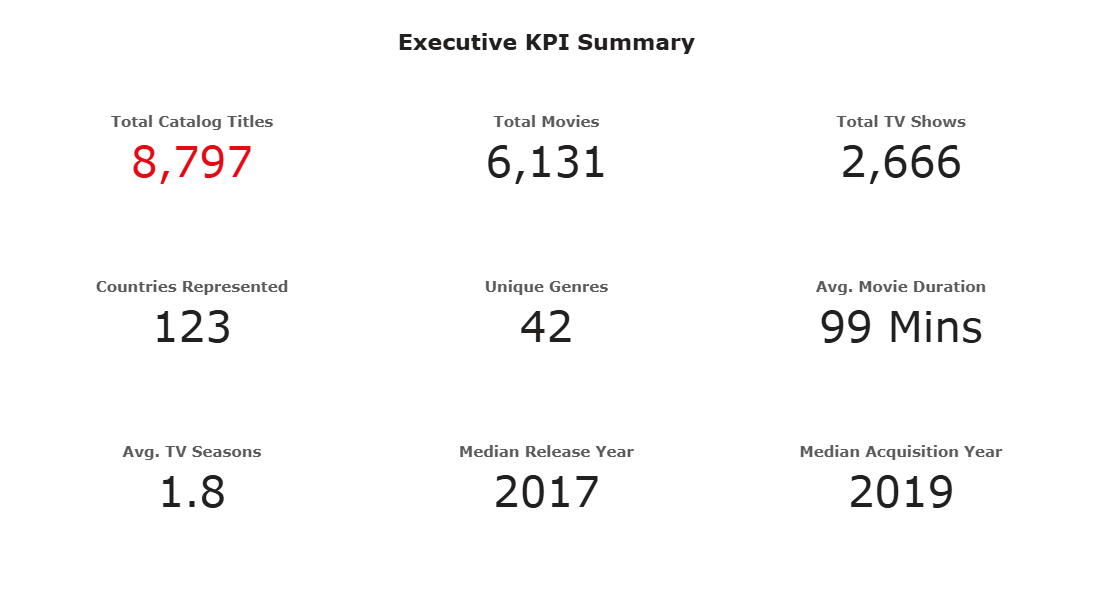

In [44]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ============================================================
# EXECUTIVE KPI SUMMARY
# ============================================================

# 1. Calculate Core Volumes
total_titles = len(df)
movies_count = len(df[df['type'] == 'Movie'])
tv_count = len(df[df['type'] == 'TV Show'])

# 2. Calculate Clean Unique Counts (Excluding missing/unknown data)
countries_count = df.explode('country_list')['country_list'].replace(['nan', 'None', '', 'Unknown'], np.nan).nunique()
genres_count = df.explode('genre_list')['genre_list'].replace(['nan', 'None', '', 'Unknown'], np.nan).nunique()

# 3. Calculate Averages and Medians
avg_movie_dur = df[df['type'] == 'Movie']['duration_value'].mean()
avg_tv_seasons = df[df['type'] == 'TV Show']['duration_value'].mean()
median_release = df['release_year'].median()
median_added = df['year_added'].median()

# 4. Build the 3x3 Subplot Grid
fig21 = make_subplots(
    rows=3, cols=3,
    specs=[[{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
           [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
           [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}]],
    vertical_spacing=0.1,
    horizontal_spacing=0.05
)

# 5. Helper Function for Clean, Standardized KPI Cards
def add_kpi(fig, value, title, row, col, valueformat="", suffix="", color=NETFLIX_COLORS['black']):
    fig.add_trace(go.Indicator(
        mode="number",
        value=value,
        # Formats the main number with custom sizing, color, and suffixes
        number={"font": {"size": 42, "color": color}, "valueformat": valueformat, "suffix": suffix},
        # Formats the title beneath/above the number in a clean, subdued gray
        title={"text": f"<b>{title}</b>", "font": {"size": 15, "color": "#5A5A5A"}}
    ), row=row, col=col)

# 6. Populate Row 1: The Core Volumes (Total highlighted in Brand Red)
add_kpi(fig21, total_titles, "Total Catalog Titles", row=1, col=1, valueformat=",", color=NETFLIX_COLORS['red'])
add_kpi(fig21, movies_count, "Total Movies", row=1, col=2, valueformat=",")
add_kpi(fig21, tv_count, "Total TV Shows", row=1, col=3, valueformat=",")

# 7. Populate Row 2: Diversity & Engagement
add_kpi(fig21, countries_count, "Countries Represented", row=2, col=1)
add_kpi(fig21, genres_count, "Unique Genres", row=2, col=2)
add_kpi(fig21, int(avg_movie_dur), "Avg. Movie Duration", row=2, col=3, suffix=" Mins")

# 8. Populate Row 3: Averages & Age
add_kpi(fig21, avg_tv_seasons, "Avg. TV Seasons", row=3, col=1, valueformat=".1f")
add_kpi(fig21, int(median_release), "Median Release Year", row=3, col=2)
add_kpi(fig21, int(median_added), "Median Acquisition Year", row=3, col=3)

# 9. Apply Final Minimalist Layout Formatting
fig21.update_layout(
    height=600,
    title=dict(
        text='<b>Executive KPI Summary</b>',
        font=dict(size=22, color=NETFLIX_COLORS['black']),
        x=0.5,
        xanchor='center'
    ),
    plot_bgcolor='#FFFFFF',
    paper_bgcolor='#FFFFFF',
    margin=dict(t=100, b=50, l=40, r=40)
)

# 10. Display the Chart
fig21.show()

In [45]:
# ============================================================
# EXPORT FINAL CLEANED DATASET FOR STREAMLIT DASHBOARD
# ============================================================

#df.to_csv(
#    'Netflix_Project_Final_V3.csv',
#    index=True,
#    index_label='show_id'
#)

#print("✅ Final cleaned dataset exported successfully.")
#print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
#print("File: Netflix_Project_Final_V3.csv")

✅ Final cleaned dataset exported successfully.
Shape: 8,797 rows × 21 columns
File: Netflix_Project_Final_Cleaned.csv
